#Shared-Backbone Embedding Network



## 1. Install & Import Libraries

In [ ]:
!pip install -U ultralytics
!pip install seaborn scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 6.7 MB/s eta 0:00:00


In [ ]:
import os, shutil, random, xml.etree.ElementTree as ET, yaml
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

from ultralytics import YOLO
from ultralytics.nn.tasks import DetectionModel

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device : {DEVICE}")
print("All libraries imported successfully.")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Device : cuda
All libraries imported successfully.


In [ ]:
!pip install -q kaggle

from google.colab import userdata
import os

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

!kaggle datasets download -d akhatova/pcb-defects -p /content/pcb_download --unzip

Dataset URL: https://www.kaggle.com/datasets/akhatova/pcb-defects
License(s): unknown
100% 1.88G/1.88G [00:11<00:00, 172MB/s]



## 2. Configuration & Dataset Setup

In [ ]:
# ── Paths ─────────────────────────────────────────────────────────────────────

root_dir    = '/content/pcb_download'
dataset_dir = os.path.join(root_dir, 'PCB_DATASET')
images_dir  = os.path.join(dataset_dir, 'images')
annot_dir   = os.path.join(dataset_dir, 'Annotations')
output_dir  = '/content/output'#

print(os.listdir(root_dir))
print(os.listdir(dataset_dir))

['PCB_DATASET']
['images', 'rotate.py', 'PCB_USED', 'Annotations', 'rotation']


In [ ]:


# ── Defect classes ─────────────────────────────────────────────────────────────
CLASSES = [
    'missing_hole',
    'mouse_bite',
    'open_circuit',
    'short',
    'spur',
    'spurious_copper',
]
NUM_CLASSES = len(CLASSES)

# ── YOLOv8 training hyper-parameters ──────────────────────────────────────────
EPOCHS      = 10
BATCH       = 16
IMG_SIZE    = 640
LR0         = 0.001
LRF         = 0.0001
MIXUP       = 0.3
CONF_THRESH = 0.25
PROJECT     = 'pcb_siamese'

# ── Siamese hyper-parameters ───────────────────────────────────────────────────
EMBED_DIM      = 256   # size of the L2-normalised embedding vector
SIAMESE_EPOCHS = 30    # more epochs for combined triplet + CE loss
SIAMESE_LR     = 1e-4
MARGIN         = 0.5   # triplet margin on L2-normalised embeddings (range [0,2])
CE_WEIGHT      = 0.5   # weight of cross-entropy loss relative to triplet loss

print(f"Classes    : {CLASSES}")
print(f"Device     : {DEVICE}")


Classes    : ['missing_hole', 'mouse_bite', 'open_circuit', 'short', 'spur', 'spurious_copper']
Device     : cuda


## 3. Parse XML Annotations & Prepare YOLO Dataset

In [ ]:
def parse_xml(xml_file):
    tree = ET.parse(xml_file)
    root = tree.getroot()
    filename = root.find('filename').text
    width  = int(root.find('size/width').text)
    height = int(root.find('size/height').text)
    data = []
    for obj in root.findall('object'):
        data.append({
            'filename': filename, 'width': width, 'height': height,
            'class': obj.find('name').text,
            'xmin': int(obj.find('bndbox/xmin').text),
            'ymin': int(obj.find('bndbox/ymin').text),
            'xmax': int(obj.find('bndbox/xmax').text),
            'ymax': int(obj.find('bndbox/ymax').text),
        })
    return data

all_data = []
for rp, _, files in os.walk(annot_dir):
    for name in files:
        if name.endswith('.xml'):
            all_data.extend(parse_xml(os.path.join(rp, name)))

annot_df = pd.DataFrame(all_data)
print(f"Total annotations: {len(annot_df)}")

# ── Resize bounding boxes to 640×640 ─────────────────────────────────────────
def resize_annotations(df, target_size=(640, 640)):
    records = []
    for _, row in df.iterrows():
        wr, hr = target_size[0] / row['width'], target_size[1] / row['height']
        records.append({
            'filename': row['filename'],
            'width': target_size[0], 'height': target_size[1],
            'class': row['class'],
            'xmin': int(row['xmin'] * wr), 'ymin': int(row['ymin'] * hr),
            'xmax': int(row['xmax'] * wr), 'ymax': int(row['ymax'] * hr),
        })
    return pd.DataFrame(records)

annot_df_r = resize_annotations(annot_df)

# ── Convert to YOLO label format ──────────────────────────────────────────────
def to_yolo(df, classes):
    records = []
    for _, r in df.iterrows():
        xc = (r['xmin'] + r['xmax']) / (2 * r['width'])
        yc = (r['ymin'] + r['ymax']) / (2 * r['height'])
        bw = (r['xmax'] - r['xmin']) / r['width']
        bh = (r['ymax'] - r['ymin']) / r['height']
        records.append((r['filename'], classes.index(r['class']), xc, yc, bw, bh))
    return records

yolo_labels = to_yolo(annot_df_r, CLASSES)

# ── 80 / 10 / 10 split ────────────────────────────────────────────────────────
def split_dataset(images_dir, labels, output_dir, train_split=0.80, val_split=0.10):
    for s in ['train', 'val', 'test']:
        os.makedirs(os.path.join(output_dir, f'images/{s}'), exist_ok=True)
        os.makedirs(os.path.join(output_dir, f'labels/{s}'), exist_ok=True)
    img_labels = {}
    for lbl in labels:
        img_labels.setdefault(lbl[0], []).append(lbl)
    fnames = list(img_labels.keys())
    random.seed(42); random.shuffle(fnames)
    n = len(fnames)
    n_train = int(n * train_split); n_val = int(n * val_split)
    splits = {
        'train': fnames[:n_train],
        'val':   fnames[n_train:n_train + n_val],
        'test':  fnames[n_train + n_val:],
    }
    for sname, filenames in splits.items():
        for fname in filenames:
            lp = os.path.join(output_dir, f'labels/{sname}', os.path.splitext(fname)[0]+'.txt')
            with open(lp, 'w') as lf:
                for _, ci, xc, yc, bw, bh in img_labels[fname]:
                    lf.write(f"{ci} {xc} {yc} {bw} {bh}\n")
            for cf in os.listdir(images_dir):
                src = os.path.join(images_dir, cf, fname)
                if os.path.exists(src):
                    shutil.copy(src, os.path.join(output_dir, f'images/{sname}/{fname}'))
                    break
    for sname, filenames in splits.items():
        print(f"  {sname:5s}: {len(filenames)} images")

os.makedirs(output_dir, exist_ok=True)
split_dataset(images_dir, yolo_labels, output_dir)

# ── Write data.yaml ───────────────────────────────────────────────────────────
data_yaml_path = os.path.join(output_dir, 'data.yaml')
with open(data_yaml_path, 'w') as f:
    yaml.safe_dump({
        'path':  os.path.abspath(output_dir),
        'train': 'images/train', 'val': 'images/val', 'test': 'images/test',
        'nc': NUM_CLASSES, 'names': CLASSES,
    }, f)
print("data.yaml written.")

Total annotations: 2953
  train: 554 images
  val  : 69 images
  test : 70 images
data.yaml written.


## 4. Siamese Twin Network Architecture

```
 Support image ──► [YOLOv8 Backbone] ──► Avg-Pool ──► Embed MLP ──►  support_emb ─┐
                         ↕ (shared weights)                                          ├─► Contrastive Loss
 Query image   ──► [YOLOv8 Backbone] ──► Avg-Pool ──► Embed MLP ──►  query_emb   ─┘
                         │
                         └──► YOLOv8 Detection Head ──► Bounding Boxes
```

Both branches use **identical, weight-tied** YOLOv8 backbone layers.  
The embedding head projects pooled features to a fixed `EMBED_DIM` space.

In [ ]:
class EmbeddingHead(nn.Module):
    """
    MLP: backbone features → L2-normalised EMBED_DIM vector.
    """
    def __init__(self, in_channels: int, embed_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_channels, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, embed_dim),
            nn.BatchNorm1d(embed_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.mean(dim=[2, 3])   # (B, C, H, W) → (B, C)
        x = self.net(x)
        return F.normalize(x, p=2, dim=1)


class ClassificationHead(nn.Module):
    def __init__(self, embed_dim: int, num_classes: int):
        super().__init__()
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, emb: torch.Tensor) -> torch.Tensor:
        return self.fc(emb)


class SiameseYOLOv8(nn.Module):
    """
    Siamese Twin Network using a YOLOv8 backbone.
    A forward hook on layer 9 of the backbone captures spatial features
    without breaking skip-connection graphs.
    """

    def __init__(self, yolo_model: YOLO, embed_dim: int = EMBED_DIM,
                 num_classes: int = NUM_CLASSES):
        super().__init__()

        self.yolo_nn = yolo_model.model          # DetectionModel
        self._embed_dim   = embed_dim
        self._num_classes = num_classes

        # ── Freeze first 4 layers; keep layers 4-9 trainable ─────────────────
        children = list(self.yolo_nn.model.children())
        for layer in children[:4]:
            for p in layer.parameters():
                p.requires_grad = False
        for layer in children[4:]:
            for p in layer.parameters():
                p.requires_grad = True

        # ── Register hook on layer 9 ──────────────────────────────────────────
        self._feat        = None
        self._hook_handle = None
        self._register_hook()

        # ── Infer channel count ───────────────────────────────────────────────
        with torch.no_grad():
            dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE,
                                device=next(self.yolo_nn.parameters()).device)
            self.yolo_nn(dummy)
            in_ch = self._feat.shape[1]
        print(f"  Hooked layer-9 feature channels : {in_ch}")

        self.embed_head   = EmbeddingHead(in_ch, embed_dim)
        self.cls_head     = ClassificationHead(embed_dim, num_classes)

    # ── Hook management ───────────────────────────────────────────────────────

    def _register_hook(self):
        """Register (or re-register) the layer-9 hook on self.yolo_nn."""
        if self._hook_handle is not None:
            try:
                self._hook_handle.remove()
            except Exception:
                pass
            self._hook_handle = None

        target = list(self.yolo_nn.model.children())[9]

        # Use default-arg capture so `_self` is bound at definition time,
        # not looked up via closure at call time.
        def _hook(module, inp, out, _self=self):
            _self._feat = out

        self._hook_handle = target.register_forward_hook(_hook)

    def clone(self):
        """
        Return a fully independent copy with its own yolo_nn and hook.

        We deepcopy yolo_nn (weights + structure) separately from the
        embedding/classification heads, then wire a fresh hook so the
        clone never shares state with the original.
        """
        import copy

        new = SiameseYOLOv8.__new__(SiameseYOLOv8)
        nn.Module.__init__(new)

        # Deep-copy the backbone — completely independent weights
        new.yolo_nn       = copy.deepcopy(self.yolo_nn)
        new._embed_dim    = self._embed_dim
        new._num_classes  = self._num_classes
        new._feat         = None
        new._hook_handle  = None

        # Deep-copy the learned heads
        new.embed_head = copy.deepcopy(self.embed_head)
        new.cls_head   = copy.deepcopy(self.cls_head)

        # Register a fresh hook on the *copied* backbone — completely isolated
        new._register_hook()

        dev = next(self.parameters()).device
        new.to(dev)
        return new

    # ── Forward methods ───────────────────────────────────────────────────────

    def extract(self, x: torch.Tensor) -> torch.Tensor:
        """Run YOLOv8 forward (hook fires), return L2-normalised embedding."""
        self._feat = None
        self.yolo_nn(x)
        if self._feat is None:
            raise RuntimeError(
                "Forward hook did not fire.\n"
                "Call model._register_hook() to restore it."
            )
        return self.embed_head(self._feat)

    def extract_with_logits(self, x: torch.Tensor):
        """Return (embedding, class_logits) in a single forward pass."""
        emb    = self.extract(x)
        logits = self.cls_head(emb)
        return emb, logits

    def forward(self, support: torch.Tensor, query: torch.Tensor):
        return self.extract(support), self.extract(query)


# ── Triplet Loss ──────────────────────────────────────────────────────────────
def triplet_loss(anchor, positive, negative, margin=MARGIN):
    d_pos = F.pairwise_distance(anchor, positive)
    d_neg = F.pairwise_distance(anchor, negative)
    return F.relu(d_pos - d_neg + margin).mean()


# ── Combined Loss = Triplet + Cross-Entropy ───────────────────────────────────
def combined_loss(anc_emb, pos_emb, neg_emb, anc_logits, anc_labels,
                  ce_weight=CE_WEIGHT):
    t_loss  = triplet_loss(anc_emb, pos_emb, neg_emb)
    ce_loss = F.cross_entropy(anc_logits, anc_labels)
    return t_loss + ce_weight * ce_loss, t_loss, ce_loss


print("Siamese architecture (hook + L2-norm + combined loss) defined.")


Siamese architecture (hook + L2-norm + combined loss) defined.


## 5. Siamese Pair Dataset

In [ ]:
# ── Shared crop helper ────────────────────────────────────────────────────────
# Used identically by: Triplet dataset, prototype builder, and inference.
# Crops the highest-confidence YOLO box from a BGR image.
# Returns a PIL RGB image (crop or full-image fallback).

_crop_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

# This will be populated once Stage 1 training is complete.
# The helper is defined here so dataset / prototype / inference cells share it.
_crop_detector = None   # set to YOLO(best_weights) after Stage 1


def crop_image(img_path: str, detector, pad: int = 10) -> torch.Tensor:
    """
    1. Run `detector` on `img_path`.
    2. Crop the highest-confidence detected box (+ `pad` pixels of border).
    3. Return a (3, IMG_SIZE, IMG_SIZE) normalised tensor.
    Falls back to the full image if no box is found.
    """
    bgr  = cv2.imread(img_path)
    crop = None

    if detector is not None:
        result = detector(img_path, imgsz=IMG_SIZE, conf=CONF_THRESH, verbose=False)[0]
        if result.boxes is not None and len(result.boxes) > 0:
            confs   = result.boxes.conf.cpu().numpy()
            best    = confs.argmax()
            x1, y1, x2, y2 = map(int, result.boxes.xyxy[best].cpu().numpy())
            h, w    = bgr.shape[:2]
            x1, y1  = max(0, x1 - pad), max(0, y1 - pad)
            x2, y2  = min(w, x2 + pad), min(h, y2 + pad)
            patch   = bgr[y1:y2, x1:x2]
            if patch.size > 0:
                crop = Image.fromarray(cv2.cvtColor(patch, cv2.COLOR_BGR2RGB))

    if crop is None:                                   # fallback: full image
        crop = Image.fromarray(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))

    return _crop_tf(crop)


print("crop_image() helper defined (detector not yet attached — will be set after Stage 1).")


crop_image() helper defined (detector not yet attached — will be set after Stage 1).


In [ ]:
class PCBTripletDataset(Dataset):
    """
    Returns (anchor, positive, negative, anchor_label) quadruples.

    Each image is represented as a **YOLO-detected defect crop** (not the full
    640×640 board image).  This focuses the embedding on the defect region and
    eliminates the signal-dilution caused by global-average-pooling over an
    almost-empty background.

    anchor        — crop of class C
    positive      — crop of a DIFFERENT image of the same class C
    negative      — crop of a different class
    anchor_label  — integer class index (for cross-entropy supervision)
    """

    def __init__(self, img_dir: str, lbl_dir: str, img_size: int = IMG_SIZE):
        # Light augmentation transform (applied inside crop_image)
        self.aug_tf = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std =[0.229, 0.224, 0.225]),
        ])

        class_to_files_raw = {i: [] for i in range(NUM_CLASSES)}
        for fname in os.listdir(img_dir):
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
            stem  = os.path.splitext(fname)[0]
            lpath = os.path.join(lbl_dir, stem + '.txt')
            if not os.path.exists(lpath):
                continue
            with open(lpath) as f:
                lines = [l.strip() for l in f if l.strip()]
            if not lines:
                continue
            cls = Counter(int(l.split()[0]) for l in lines).most_common(1)[0][0]
            class_to_files_raw[cls].append(os.path.join(img_dir, fname))

        # Only keep classes with >= 2 images (need distinct anchor & positive)
        self.class_to_files = {c: fps for c, fps in class_to_files_raw.items()
                               if len(fps) >= 2}
        self.valid_classes  = sorted(self.class_to_files.keys())
        self.samples = [
            (fp, cls)
            for cls in self.valid_classes
            for fp in self.class_to_files[cls]
        ]
        skipped = sum(len(v) for c, v in class_to_files_raw.items()
                      if c not in self.class_to_files)
        print(f"  Triplet dataset : {len(self.samples)} images, "
              f"{len(self.valid_classes)} valid classes "
              f"({skipped} images skipped — class has < 2 samples)")

    def _load(self, path: str) -> torch.Tensor:
        """Load image: crop the highest-conf YOLO box, apply augmentation."""
        bgr  = cv2.imread(path)
        crop = None

        if _crop_detector is not None:
            result = _crop_detector(path, imgsz=IMG_SIZE, conf=CONF_THRESH,
                                    verbose=False)[0]
            if result.boxes is not None and len(result.boxes) > 0:
                confs  = result.boxes.conf.cpu().numpy()
                best   = confs.argmax()
                x1, y1, x2, y2 = map(int, result.boxes.xyxy[best].cpu().numpy())
                h, w   = bgr.shape[:2]
                pad    = 10
                x1, y1 = max(0, x1-pad), max(0, y1-pad)
                x2, y2 = min(w, x2+pad), min(h, y2+pad)
                patch  = bgr[y1:y2, x1:x2]
                if patch.size > 0:
                    crop = Image.fromarray(cv2.cvtColor(patch, cv2.COLOR_BGR2RGB))

        if crop is None:
            crop = Image.fromarray(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))

        return self.aug_tf(crop)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        anchor_path, anchor_cls = self.samples[idx]

        # Positive: a DIFFERENT image of the same class
        pos_candidates = [p for p in self.class_to_files[anchor_cls]
                          if p != anchor_path]
        positive_path = random.choice(pos_candidates)

        # Negative: image from a different class
        neg_cls       = random.choice([c for c in self.valid_classes
                                       if c != anchor_cls])
        negative_path = random.choice(self.class_to_files[neg_cls])

        return (
            self._load(anchor_path),
            self._load(positive_path),
            self._load(negative_path),
            anchor_cls,
        )


# ── NOTE: datasets are built AFTER Stage 1 so _crop_detector is available ─────
# They are constructed in the cell that follows Stage 1 training.
print("PCBTripletDataset class defined — will be instantiated after Stage 1.")


PCBTripletDataset class defined — will be instantiated after Stage 1.


## 6. Stage 1 — Train YOLOv8 Detector

In [ ]:
yolo_model = YOLO('yolov8s.pt')

train_results = yolo_model.train(
    data       = data_yaml_path,
    epochs     = EPOCHS,
    batch      = BATCH,
    imgsz      = IMG_SIZE,
    lr0        = LR0,
    lrf        = LRF,
    mixup      = MIXUP,
    project    = PROJECT,
    name       = 'detect',
    save_period= 1,
    verbose    = True,
)

# Capture paths dynamically — works on Kaggle
best_weights = str(yolo_model.trainer.best)
save_dir     = str(yolo_model.trainer.save_dir)
results_csv  = os.path.join(save_dir, 'results.csv')

print("\nStage 1 complete.")
print("Best weights :", best_weights)
print("Save dir     :", save_dir)


Ultralytics 8.4.150 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/output/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.0001, mask_ratio=4, max_det=300, mixup=0.3, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=detect, nbs=64, nms=None, opset=None, optimize=F

## 7. Training Curves (Loss & mAP)

In [ ]:
# Load the best YOLOv8 checkpoint produced by Stage 1
model_best = YOLO(best_weights)
print(f"Loaded best weights: {best_weights}")

# ── Attach the crop detector so the triplet dataset uses YOLO crops ───────────
# (global variable used by crop_image() and PCBTripletDataset._load)
import sys
_crop_detector = YOLO(best_weights)
# Replace the module-level reference so the helper cell's reference is updated
sys.modules[__name__].__dict__['_crop_detector'] = _crop_detector
print("Crop detector attached — triplet dataset will crop YOLO-detected regions.")

# ── Build triplet datasets now that _crop_detector is available ───────────────
print("\nBuilding triplet datasets from YOLO-cropped images …")
train_triplet_ds = PCBTripletDataset(
    os.path.join(output_dir, 'images/train'),
    os.path.join(output_dir, 'labels/train'),
)
val_triplet_ds = PCBTripletDataset(
    os.path.join(output_dir, 'images/val'),
    os.path.join(output_dir, 'labels/val'),
)

train_triplet_loader = DataLoader(train_triplet_ds, batch_size=16, shuffle=True,
                                  num_workers=0, pin_memory=True)
val_triplet_loader   = DataLoader(val_triplet_ds,   batch_size=16, shuffle=False,
                                  num_workers=0, pin_memory=True)
print("Triplet loaders ready.")


Loaded best weights: /content/runs/detect/pcb_siamese/detect/weights/best.pt
Crop detector attached — triplet dataset will crop YOLO-detected regions.

Building triplet datasets from YOLO-cropped images …
  Triplet dataset : 554 images, 6 valid classes (0 images skipped — class has < 2 samples)
  Triplet dataset : 69 images, 6 valid classes (0 images skipped — class has < 2 samples)
Triplet loaders ready.


Loaded results.csv with 10 epoch rows.


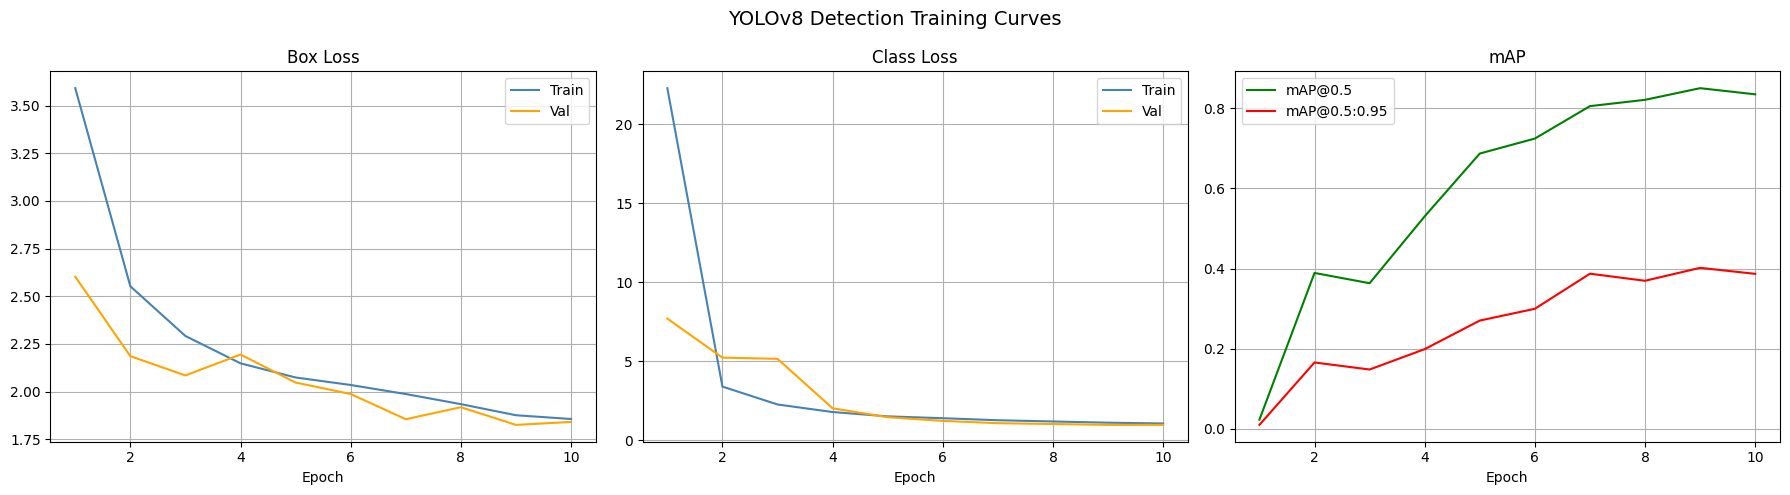

In [ ]:
if os.path.exists(results_csv):
    res_df = pd.read_csv(results_csv)
    res_df.columns = res_df.columns.str.strip()
    res_df = res_df.apply(pd.to_numeric, errors='coerce').dropna()
    print(f"Loaded results.csv with {len(res_df)} epoch rows.")
else:
    raise FileNotFoundError(f"results.csv not found at {results_csv}.")

epochs_range = res_df['epoch']
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].plot(epochs_range, res_df['train/box_loss'], label='Train', color='steelblue')
axs[0].plot(epochs_range, res_df['val/box_loss'],   label='Val',   color='orange')
axs[0].set_title('Box Loss'); axs[0].set_xlabel('Epoch'); axs[0].legend(); axs[0].grid(True)

axs[1].plot(epochs_range, res_df['train/cls_loss'], label='Train', color='steelblue')
axs[1].plot(epochs_range, res_df['val/cls_loss'],   label='Val',   color='orange')
axs[1].set_title('Class Loss'); axs[1].set_xlabel('Epoch'); axs[1].legend(); axs[1].grid(True)

axs[2].plot(epochs_range, res_df['metrics/mAP50(B)'],    label='mAP@0.5',      color='green')
axs[2].plot(epochs_range, res_df['metrics/mAP50-95(B)'], label='mAP@0.5:0.95', color='red')
axs[2].set_title('mAP'); axs[2].set_xlabel('Epoch'); axs[2].legend(); axs[2].grid(True)

plt.suptitle('YOLOv8 Detection Training Curves', fontsize=14)
plt.tight_layout(); plt.show()

## 8. Stage 2 — Fine-tune Siamese Twin Network with Contrastive Loss

Stage 2 — Siamese fine-tuning (triplet + cross-entropy combined loss)
  Hooked layer-9 feature channels : 512
  Trainable parameters : 11,412,456
  Epoch   1/30 | total=1.2958  triplet=0.4094  ce=1.7727  val=1.1646  lr=9.97e-05
  Epoch   2/30 | total=1.1230  triplet=0.2673  ce=1.7114  val=0.9918  lr=9.89e-05
  Epoch   3/30 | total=1.0564  triplet=0.2296  ce=1.6537  val=0.9567  lr=9.76e-05
  Epoch   4/30 | total=0.9666  triplet=0.1723  ce=1.5888  val=0.9115  lr=9.57e-05
  Epoch   5/30 | total=0.9119  triplet=0.1445  ce=1.5348  val=0.8399  lr=9.34e-05
  Epoch   6/30 | total=0.8568  triplet=0.1224  ce=1.4687  val=0.8069  lr=9.05e-05
  Epoch   7/30 | total=0.8370  triplet=0.1222  ce=1.4296  val=0.8210  lr=8.73e-05
  Epoch   8/30 | total=0.7967  triplet=0.1049  ce=1.3837  val=0.7841  lr=8.36e-05
  Epoch   9/30 | total=0.7722  triplet=0.1041  ce=1.3361  val=0.7081  lr=7.96e-05
  Epoch  10/30 | total=0.7263  triplet=0.0792  ce=1.2943  val=0.7319  lr=7.52e-05
  Epoch  11/30 | total=0.7262  tri

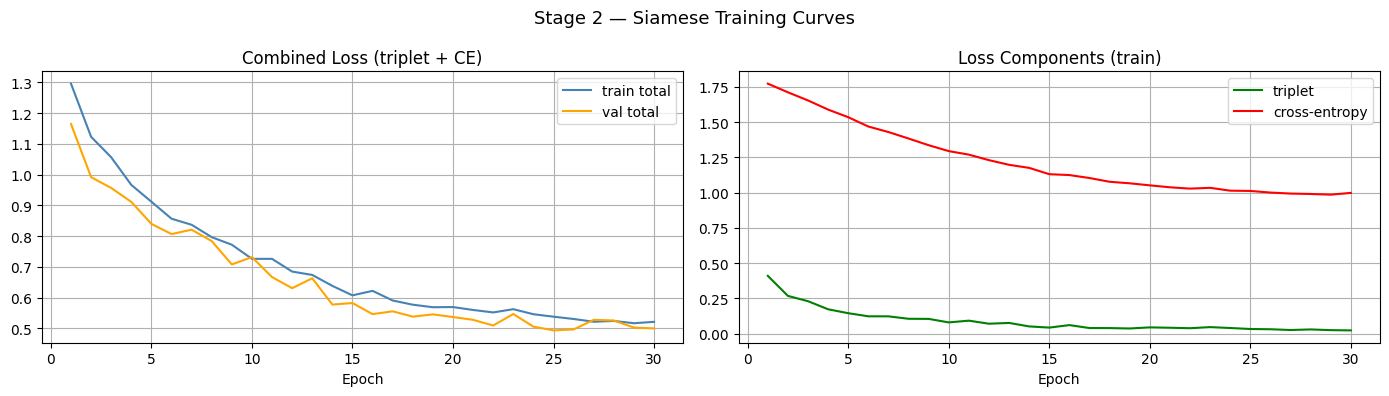

In [13]:
print("Stage 2 — Siamese fine-tuning (triplet + cross-entropy combined loss)")

# Build the Siamese model on top of the trained YOLOv8 detector
siamese_net = SiameseYOLOv8(model_best, embed_dim=EMBED_DIM,
                             num_classes=NUM_CLASSES).to(DEVICE)

# Only update parameters that require grad (backbone layers 4-9 + heads)
trainable = [p for p in siamese_net.parameters() if p.requires_grad]
print(f"  Trainable parameters : {sum(p.numel() for p in trainable):,}")

optimizer = torch.optim.AdamW(trainable, lr=SIAMESE_LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=SIAMESE_EPOCHS, eta_min=1e-6
)

best_val_loss = float('inf')
best_state    = None
train_losses, val_losses     = [], []
train_t_losses, train_ce_losses = [], []

for epoch in range(1, SIAMESE_EPOCHS + 1):
    # ── Training ──────────────────────────────────────────────────────────────
    siamese_net.train()
    run_total = run_t = run_ce = 0.0

    for anchor, positive, negative, anc_labels in train_triplet_loader:
        anchor     = anchor.to(DEVICE)
        positive   = positive.to(DEVICE)
        negative   = negative.to(DEVICE)
        anc_labels = anc_labels.to(DEVICE)

        # Single forward pass per image (embeddings + logits for anchor)
        anc_emb, anc_logits = siamese_net.extract_with_logits(anchor)
        pos_emb              = siamese_net.extract(positive)
        neg_emb              = siamese_net.extract(negative)

        loss, t_loss, ce_loss = combined_loss(
            anc_emb, pos_emb, neg_emb,
            anc_logits, anc_labels,
        )

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(trainable, max_norm=1.0)
        optimizer.step()

        run_total += loss.item()
        run_t     += t_loss.item()
        run_ce    += ce_loss.item()

    n = len(train_triplet_loader)
    avg_train    = run_total / n
    avg_t_loss   = run_t    / n
    avg_ce_loss  = run_ce   / n
    train_losses.append(avg_train)
    train_t_losses.append(avg_t_loss)
    train_ce_losses.append(avg_ce_loss)

    # ── Validation ────────────────────────────────────────────────────────────
    siamese_net.eval()
    val_run = 0.0
    with torch.no_grad():
        for anchor, positive, negative, anc_labels in val_triplet_loader:
            anchor     = anchor.to(DEVICE)
            positive   = positive.to(DEVICE)
            negative   = negative.to(DEVICE)
            anc_labels = anc_labels.to(DEVICE)

            anc_emb, anc_logits = siamese_net.extract_with_logits(anchor)
            pos_emb              = siamese_net.extract(positive)
            neg_emb              = siamese_net.extract(negative)

            loss, _, _ = combined_loss(anc_emb, pos_emb, neg_emb,
                                       anc_logits, anc_labels)
            val_run += loss.item()

    avg_val = val_run / max(len(val_triplet_loader), 1)
    val_losses.append(avg_val)

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        best_state    = {k: v.cpu().clone() for k, v in siamese_net.state_dict().items()}

    scheduler.step()
    print(f"  Epoch {epoch:3d}/{SIAMESE_EPOCHS} | "
          f"total={avg_train:.4f}  triplet={avg_t_loss:.4f}  "
          f"ce={avg_ce_loss:.4f}  val={avg_val:.4f}  "
          f"lr={scheduler.get_last_lr()[0]:.2e}")

# Restore best weights
if best_state is not None:
    siamese_net.load_state_dict(best_state)
    print(f"\n Restored best weights (val_loss={best_val_loss:.4f})")

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ep = range(1, SIAMESE_EPOCHS + 1)

axes[0].plot(ep, train_losses, label='train total', color='steelblue')
axes[0].plot(ep, val_losses,   label='val total',   color='orange')
axes[0].set_title('Combined Loss (triplet + CE)'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(ep, train_t_losses,  label='triplet', color='green')
axes[1].plot(ep, train_ce_losses, label='cross-entropy', color='red')
axes[1].set_title('Loss Components (train)'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True)

plt.suptitle('Stage 2 — Siamese Training Curves', fontsize=13)
plt.tight_layout()
plt.show()


## 9. Build Support Set (Reference Embeddings per Class)

In [14]:
def build_prototypes(k: int = None, verbose: bool = True) -> dict:
    """
    Build one mean-prototype embedding per defect class from YOLO-cropped
    training images.

    Parameters
    ----------
    k : int or None
        Number of support images per class (K-shot).
        None = use ALL available training images (full-shot baseline).
    verbose : bool
        Print per-class stats table when True.

    Returns
    -------
    dict[int, torch.Tensor]   class_idx → L2-normalised prototype (EMBED_DIM,)
    """
    train_img_dir = os.path.join(output_dir, 'images/train')
    train_lbl_dir = os.path.join(output_dir, 'labels/train')

    # ── Gather all training image paths per class ─────────────────────────────
    class_to_paths: dict[int, list] = {i: [] for i in range(NUM_CLASSES)}
    for fname in sorted(os.listdir(train_img_dir)):
        if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        stem  = os.path.splitext(fname)[0]
        lpath = os.path.join(train_lbl_dir, stem + '.txt')
        if not os.path.exists(lpath):
            continue
        with open(lpath) as f:
            lines = [l.strip() for l in f if l.strip()]
        if not lines:
            continue
        cls = Counter(int(l.split()[0]) for l in lines).most_common(1)[0][0]
        class_to_paths[cls].append(os.path.join(train_img_dir, fname))

    # ── Sample K images per class (or all if k is None) ───────────────────────
    class_embeddings: dict[int, list] = {}
    siamese_net.eval()
    with torch.no_grad():
        for cls_idx, paths in class_to_paths.items():
            if not paths:
                continue
            selected = paths if k is None else random.sample(paths, min(k, len(paths)))
            embs = []
            for img_path in selected:
                crop_t = crop_image(img_path, _crop_detector)
                emb    = siamese_net.extract(crop_t.unsqueeze(0).to(DEVICE))
                embs.append(emb.squeeze(0).cpu())
            class_embeddings[cls_idx] = embs

    # ── Mean prototype + re-normalise ─────────────────────────────────────────
    prototypes: dict[int, torch.Tensor] = {}
    if verbose:
        label_k = 'all' if k is None else str(k)
        print(f"\n── Prototypes (k={label_k}) ──────────────────────────────────")
        print(f"  {'Class':<20}  {'#imgs':>5}  {'intra-var':>10}  proto-norm")
        print("  " + "-" * 52)

    for cls_idx in range(NUM_CLASSES):
        embs = class_embeddings.get(cls_idx, [])
        if not embs:
            continue
        stack    = torch.stack(embs, dim=0)
        mean_emb = stack.mean(dim=0)
        proto    = F.normalize(mean_emb, p=2, dim=0)
        prototypes[cls_idx] = proto

        if verbose:
            intra_var = ((stack - proto.unsqueeze(0)).pow(2).sum(dim=1)).mean().item()
            print(f"  {CLASSES[cls_idx]:<20}  {len(embs):>5}  {intra_var:>10.4f}  "
                  f"{proto.norm().item():.4f}")

    if verbose:
        print(f"\n  Built {len(prototypes)} prototypes.")
    return prototypes


# ── Build the default full-shot prototypes used by the rest of the notebook ────
support_prototypes = build_prototypes(k=None, verbose=True)



── Prototypes (k=all) ──────────────────────────────────
  Class                 #imgs   intra-var  proto-norm
  ----------------------------------------------------
  missing_hole             84      0.0038  1.0000
  mouse_bite               96      0.1333  1.0000
  open_circuit             96      0.0701  1.0000
  short                    93      0.0057  1.0000
  spur                     95      0.1060  1.0000
  spurious_copper          90      0.1028  1.0000

  Built 6 prototypes.


## 10. Run Inference on Test Set (YOLOv8 Detection + Siamese Classification)

In [ ]:
def get_gt_class(image_name: str, label_dir: str):
    """Return dominant ground-truth class index (int) or None."""
    stem  = os.path.splitext(image_name)[0]
    lpath = os.path.join(label_dir, stem + '.txt')
    if not os.path.exists(lpath):
        return None
    with open(lpath) as f:
        lines = [l.strip() for l in f if l.strip()]
    if not lines:
        return None
    return Counter(int(l.split()[0]) for l in lines).most_common(1)[0][0]


def siamese_classify(img_path: str) -> int:
    """
    Classify via the trained cross-entropy head (primary) using a YOLO crop.

    Pipeline:
      1. Crop the highest-confidence YOLO-detected defect region.
      2. Embed the crop through the shared backbone + EmbeddingHead.
      3. Pass embedding through ClassificationHead → argmax class.

    Using the CE head (trained jointly with triplet loss) directly is more
    accurate than nearest-prototype because it learned a direct decision
    boundary during Stage 2 training.

    Falls back to nearest-prototype cosine matching if prototypes are available
    and CE confidence is low.
    """
    crop_tensor = crop_image(img_path, _crop_detector)
    img_tensor  = crop_tensor.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        emb, logits = siamese_net.extract_with_logits(img_tensor)

    # ── Primary: CE head argmax ───────────────────────────────────────────────
    probs    = torch.softmax(logits, dim=1)
    ce_conf, ce_pred = probs.max(dim=1)
    ce_pred  = ce_pred.item()
    ce_conf  = ce_conf.item()

    # ── Fallback: nearest-prototype cosine similarity (if CE confidence < 0.4) ─
    if ce_conf < 0.4 and support_prototypes:
        qry_emb  = emb.squeeze(0).cpu()
        best_cls, best_sim = -1, -float('inf')
        for cls_idx, proto in support_prototypes.items():
            sim = torch.dot(qry_emb, proto).item()
            if sim > best_sim:
                best_sim, best_cls = sim, cls_idx
        return best_cls

    return ce_pred


# ── Evaluate on test set ──────────────────────────────────────────────────────
test_img_dir   = os.path.join(output_dir, 'images/test')
test_label_dir = os.path.join(output_dir, 'labels/test')
test_images    = sorted(
    f for f in os.listdir(test_img_dir)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
)

# det_model used for YOLOv8 evaluation AND as crop detector for Siamese
det_model = YOLO(best_weights)

y_true, y_pred_yolo, y_pred_siamese = [], [], []

for img_name in test_images:
    gt = get_gt_class(img_name, test_label_dir)
    if gt is None:
        continue

    img_path = os.path.join(test_img_dir, img_name)

    # ── YOLOv8 detection-based prediction ────────────────────────────────────
    result = det_model(img_path, imgsz=IMG_SIZE, conf=CONF_THRESH, verbose=False)[0]
    boxes  = result.boxes
    if boxes is not None and len(boxes) > 0:
        confs   = boxes.conf.cpu().numpy()
        cls_ids = boxes.cls.cpu().numpy().astype(int)
        mask    = confs >= CONF_THRESH
        yolo_pred = int(cls_ids[mask][confs[mask].argmax()]) if mask.any() else -1
    else:
        yolo_pred = -1

    # ── Siamese: crop → CE head (with proto fallback) ────────────────────────
    siam_pred = siamese_classify(img_path)

    y_true.append(gt)
    y_pred_yolo.append(yolo_pred)
    y_pred_siamese.append(siam_pred)

print(f"Test images evaluated : {len(y_true)}")
print(f"YOLOv8  detections    : {sum(p != -1 for p in y_pred_yolo)}")
print(f"Siamese predictions   : {sum(p != -1 for p in y_pred_siamese)}")


## 11. Accuracy

In [16]:
# ── YOLOv8-only accuracy (baseline, same method as simple notebook) ───────────
paired_yolo     = [(gt, pr) for gt, pr in zip(y_true, y_pred_yolo)     if pr != -1]
y_true_yolo     = [p[0] for p in paired_yolo]
y_pred_yolo_f   = [p[1] for p in paired_yolo]
acc_yolo        = accuracy_score(y_true_yolo, y_pred_yolo_f)

# ── Siamese accuracy ──────────────────────────────────────────────────────────
paired_siam     = [(gt, pr) for gt, pr in zip(y_true, y_pred_siamese)  if pr != -1]
y_true_siam     = [p[0] for p in paired_siam]
y_pred_siam_f   = [p[1] for p in paired_siam]
acc_siam        = accuracy_score(y_true_siam, y_pred_siam_f)

print("=" * 60)
print(f"  YOLOv8  Detection Accuracy  : {acc_yolo * 100:.2f}%  "
      f"({len(y_true_yolo)}/{len(y_true)} detected)")
print(f"  Siamese Classification Acc  : {acc_siam * 100:.2f}%  "
      f"({len(y_true_siam)}/{len(y_true)} classified)")
print("=" * 60)

  YOLOv8  Detection Accuracy  : 100.00%  (64/70 detected)
  Siamese Classification Acc  : 92.86%  (70/70 classified)


## 12. Confusion Matrices

In [ ]:
def plot_cm(y_t, y_p, title, cmap='Blues', normalise=False):
    labels  = sorted(set(y_t) | set(y_p))
    names   = [CLASSES[i] for i in labels]
    cm      = confusion_matrix(y_t, y_p, labels=labels,
                               normalize='true' if normalise else None)
    fmt     = '.2f' if normalise else 'd'
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt=fmt, cmap=cmap,
                xticklabels=names, yticklabels=names,
                linewidths=0.5, vmin=0, vmax=1 if normalise else None, ax=ax)
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('True',      fontsize=12)
    ax.set_title(title, fontsize=13)
    plt.xticks(rotation=30, ha='right'); plt.yticks(rotation=0)
    plt.tight_layout(); plt.show()

# ── YOLOv8 confusion matrices ─────────────────────────────────────────────────
plot_cm(y_true_yolo, y_pred_yolo_f,
        'Confusion Matrix — YOLOv8 Detection',    cmap='Blues')
plot_cm(y_true_yolo, y_pred_yolo_f,
        'Normalised CM — YOLOv8 Detection',       cmap='YlOrRd', normalise=True)

# ── Siamese confusion matrices ────────────────────────────────────────────────
plot_cm(y_true_siam, y_pred_siam_f,
        'Confusion Matrix — Siamese Classification',   cmap='Blues')
plot_cm(y_true_siam, y_pred_siam_f,
        'Normalised CM — Siamese Classification',      cmap='YlOrRd', normalise=True)

## 13. Classification Reports

In [18]:
def styled_report(y_t, y_p, title):
    labels  = sorted(set(y_t) | set(y_p))
    names   = [CLASSES[i] for i in labels]
    rstr    = classification_report(y_t, y_p, labels=labels, target_names=names, digits=4)
    print(f"\n{'='*65}")
    print(f"  {title}")
    print('='*65)
    print(rstr)

    rdict = classification_report(y_t, y_p, labels=labels, target_names=names,
                                  digits=4, output_dict=True)
    rdf = pd.DataFrame(rdict).T
    rdf['support'] = rdf['support'].astype(int)
    return (
        rdf.style
        .format({'precision': '{:.4f}', 'recall': '{:.4f}', 'f1-score': '{:.4f}'})
        .background_gradient(cmap='RdYlGn', subset=['precision', 'recall', 'f1-score'])
        .set_caption(title)
        .set_table_styles([{'selector': 'caption',
                            'props': [('font-size', '14px'), ('font-weight', 'bold')]}])
    ), rdict

print("── YOLOv8 Detection Report ──────────────────────────────────────────────")
styled_yolo, rdict_yolo = styled_report(y_true_yolo, y_pred_yolo_f, "YOLOv8 Detection — Classification Report")
styled_yolo

── YOLOv8 Detection Report ──────────────────────────────────────────────

  YOLOv8 Detection — Classification Report
                 precision    recall  f1-score   support

   missing_hole     1.0000    1.0000    1.0000        15
     mouse_bite     1.0000    1.0000    1.0000         5
   open_circuit     1.0000    1.0000    1.0000        10
          short     1.0000    1.0000    1.0000        11
           spur     1.0000    1.0000    1.0000         7
spurious_copper     1.0000    1.0000    1.0000        16

       accuracy                         1.0000        64
      macro avg     1.0000    1.0000    1.0000        64
   weighted avg     1.0000    1.0000    1.0000        64



,precision,recall,f1-score,support
missing_hole,1.0000,1.0000,1.0000,15
mouse_bite,1.0000,1.0000,1.0000,5
open_circuit,1.0000,1.0000,1.0000,10
short,1.0000,1.0000,1.0000,11
spur,1.0000,1.0000,1.0000,7
spurious_copper,1.0000,1.0000,1.0000,16
accuracy,1.0000,1.0000,1.0000,1
macro avg,1.0000,1.0000,1.0000,64
weighted avg,1.0000,1.0000,1.0000,64


In [19]:
print("── Siamese Classification Report ────────────────────────────────────────")
styled_siam, rdict_siam = styled_report(y_true_siam, y_pred_siam_f, "Siamese Network — Classification Report")
styled_siam

── Siamese Classification Report ────────────────────────────────────────

  Siamese Network — Classification Report
                 precision    recall  f1-score   support

   missing_hole     1.0000    1.0000    1.0000        15
     mouse_bite     1.0000    0.7143    0.8333         7
   open_circuit     1.0000    1.0000    1.0000        11
          short     1.0000    0.8182    0.9000        11
           spur     0.6923    1.0000    0.8182         9
spurious_copper     0.9412    0.9412    0.9412        17

       accuracy                         0.9286        70
      macro avg     0.9389    0.9123    0.9154        70
   weighted avg     0.9462    0.9286    0.9300        70



,precision,recall,f1-score,support
missing_hole,1.0000,1.0000,1.0000,15
mouse_bite,1.0000,0.7143,0.8333,7
open_circuit,1.0000,1.0000,1.0000,11
short,1.0000,0.8182,0.9000,11
spur,0.6923,1.0000,0.8182,9
spurious_copper,0.9412,0.9412,0.9412,17
accuracy,0.9286,0.9286,0.9286,0
macro avg,0.9389,0.9123,0.9154,70
weighted avg,0.9462,0.9286,0.9300,70


## 14. Per-Class F1 Bar Chart (YOLOv8 vs Siamese)

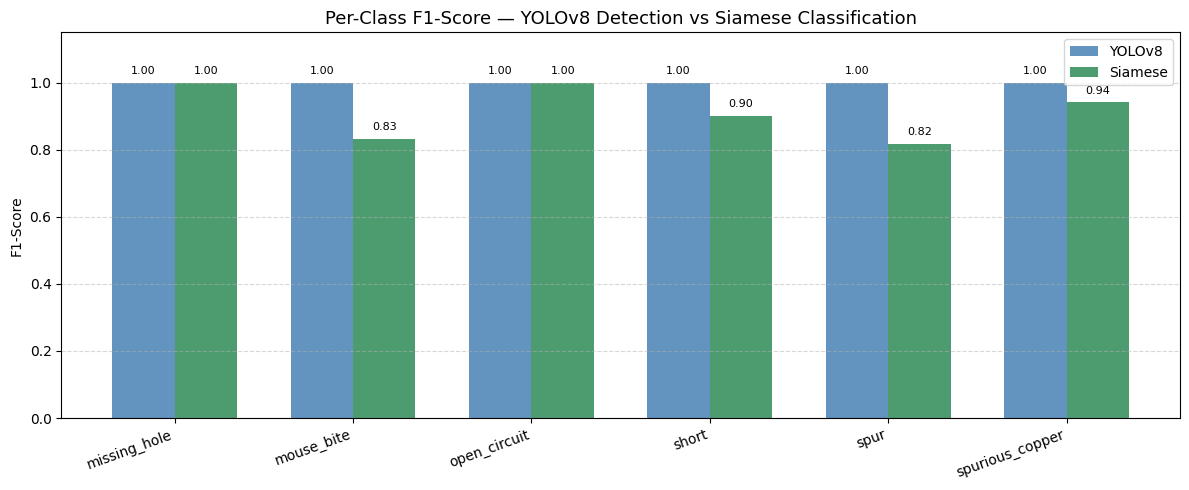

In [20]:
all_cls = sorted(set(y_true_yolo) | set(y_true_siam))
cls_names = [CLASSES[i] for i in all_cls]

f1_yolo   = [rdict_yolo.get(CLASSES[i], {}).get('f1-score', 0)  for i in all_cls]
f1_siam   = [rdict_siam.get(CLASSES[i], {}).get('f1-score', 0)  for i in all_cls]

x = np.arange(len(cls_names))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars_y = ax.bar(x - w/2, f1_yolo, w, label='YOLOv8',  color='steelblue',  alpha=0.85)
bars_s = ax.bar(x + w/2, f1_siam, w, label='Siamese', color='seagreen',   alpha=0.85)

ax.set_xticks(x); ax.set_xticklabels(cls_names, rotation=20, ha='right')
ax.set_ylim(0, 1.15); ax.set_ylabel('F1-Score')
ax.set_title('Per-Class F1-Score — YOLOv8 Detection vs Siamese Classification', fontsize=13)
ax.legend(); ax.grid(axis='y', linestyle='--', alpha=0.5)

for bars in [bars_y, bars_s]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.02,
                f'{h:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout(); plt.show()

## 15. Sample Predictions Visualisation

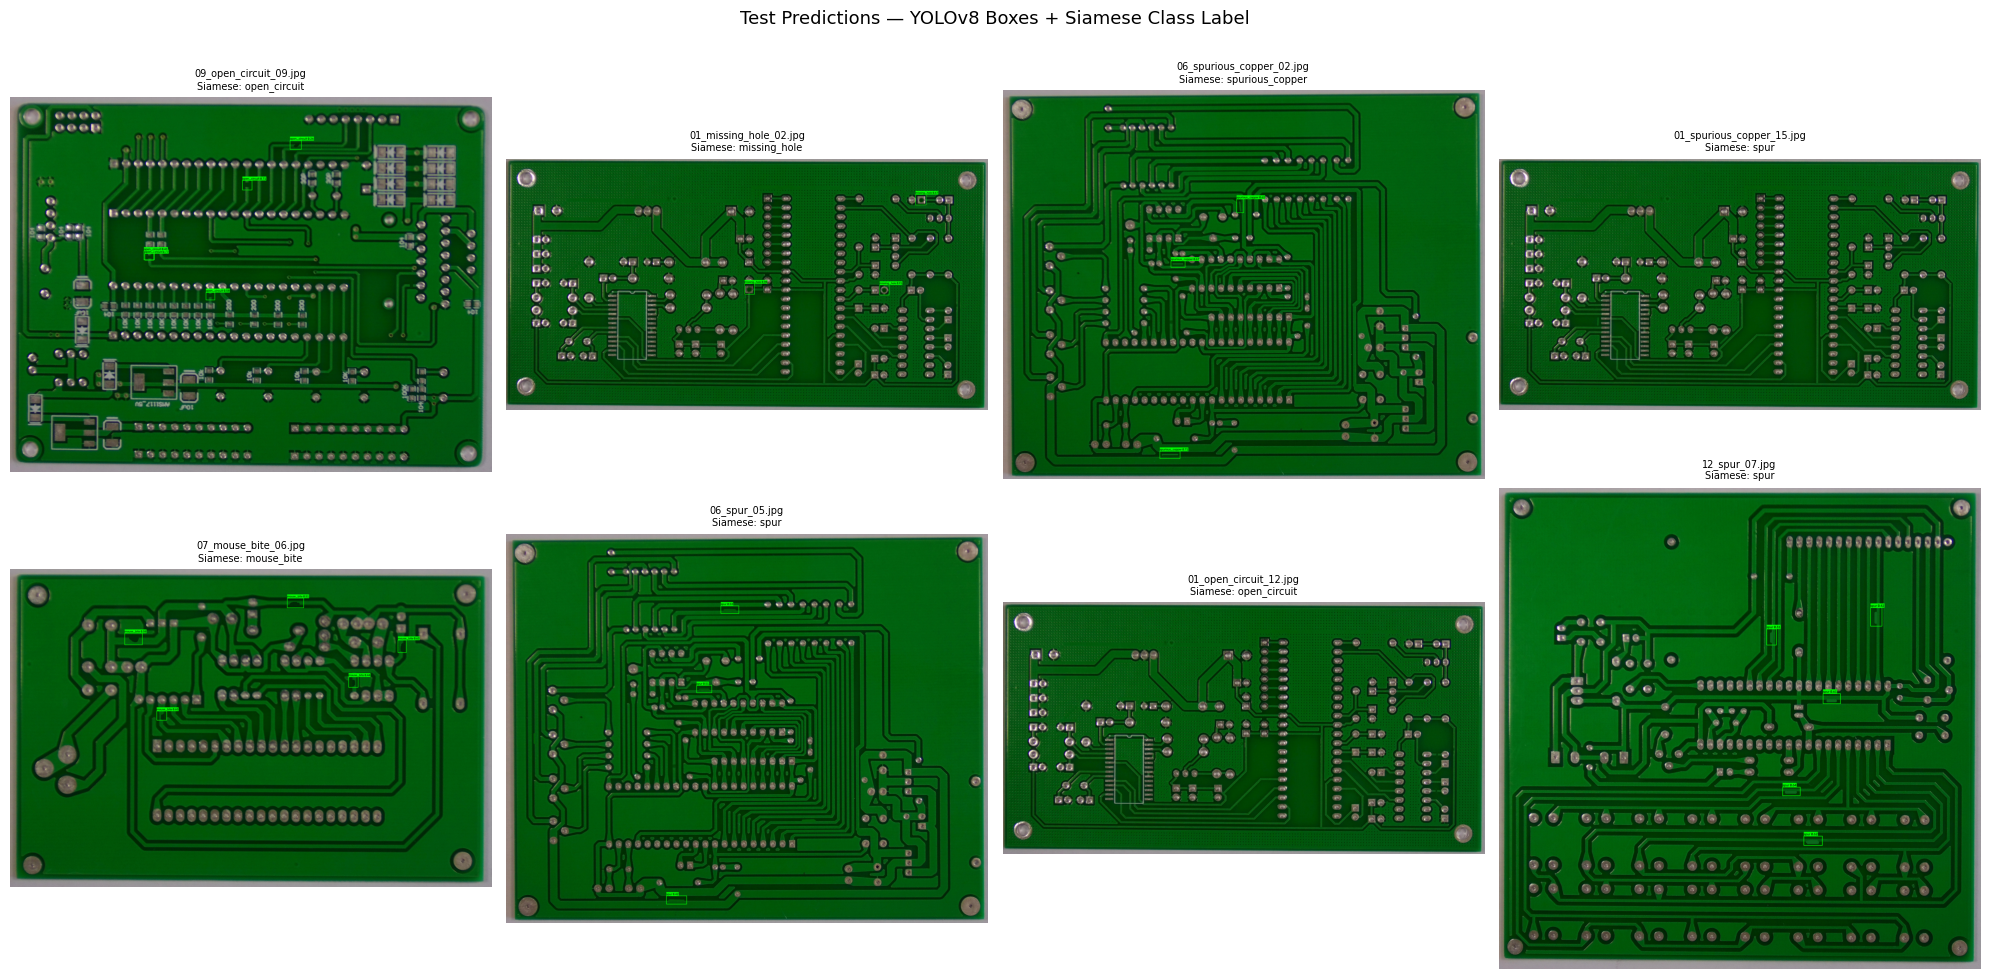

In [21]:
def draw_boxes(bgr, boxes_obj, class_names, color=(0, 255, 0)):
    img = bgr.copy()
    if boxes_obj is None or len(boxes_obj) == 0:
        return img
    for box in boxes_obj:
        x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
        ci   = int(box.cls.cpu().numpy()[0])
        conf = float(box.conf.cpu().numpy()[0])
        lbl  = f"{class_names[ci]} {conf:.2f}"
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        (tw, th), _ = cv2.getTextSize(lbl, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 1)
        cv2.rectangle(img, (x1, y1-th-6), (x1+tw, y1), color, -1)
        cv2.putText(img, lbl, (x1, y1-4), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 1)
    return img

sample_imgs = random.sample(test_images, min(8, len(test_images)))
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for ax, img_name in zip(axes.flat, sample_imgs):
    img_path   = os.path.join(test_img_dir, img_name)
    bgr        = cv2.imread(img_path)
    result     = det_model(img_path, imgsz=IMG_SIZE, conf=CONF_THRESH, verbose=False)[0]
    drawn      = draw_boxes(bgr, result.boxes, CLASSES)
    siam_cls   = siamese_classify(img_path)
    siam_label = CLASSES[siam_cls] if siam_cls != -1 else 'none'
    ax.imshow(cv2.cvtColor(drawn, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{img_name}\nSiamese: {siam_label}", fontsize=7)
    ax.axis('off')

plt.suptitle('Test Predictions — YOLOv8 Boxes + Siamese Class Label', fontsize=13)
plt.tight_layout(); plt.show()

## 16. Summary

In [22]:
ma_yolo = rdict_yolo.get('macro avg', {})
ma_siam = rdict_siam.get('macro avg', {})

print("╔══════════════════════════════════════════════════════════════╗")
print("║     PCB Defect Detection — Siamese + YOLOv8 Summary          ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  Backbone         : YOLOv8s (yolov8s.pt)                    ║")
print(f"║  Detection epochs : {EPOCHS:<41} ║")
print(f"║  Siamese epochs   : {SIAMESE_EPOCHS:<41} ║")
print(f"║  Embed dim        : {EMBED_DIM:<41} ║")
print(f"║  Classes          : {NUM_CLASSES:<41} ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║              {'YOLOv8':>12}    {'Siamese':>12}                ║")
print(f"║  Accuracy  : {acc_yolo*100:>10.2f}%  {acc_siam*100:>10.2f}%                ║")
print(f"║  Macro P   : {ma_yolo.get('precision',0):>12.4f}  {ma_siam.get('precision',0):>12.4f}                ║")
print(f"║  Macro R   : {ma_yolo.get('recall',0):>12.4f}  {ma_siam.get('recall',0):>12.4f}                ║")
print(f"║  Macro F1  : {ma_yolo.get('f1-score',0):>12.4f}  {ma_siam.get('f1-score',0):>12.4f}                ║")
print("╚══════════════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════════╗
║     PCB Defect Detection — Siamese + YOLOv8 Summary          ║
╠══════════════════════════════════════════════════════════════╣
║  Backbone         : YOLOv8s (yolov8s.pt)                    ║
║  Detection epochs : 10                                        ║
║  Siamese epochs   : 30                                        ║
║  Embed dim        : 256                                       ║
║  Classes          : 6                                         ║
╠══════════════════════════════════════════════════════════════╣
║                    YOLOv8         Siamese                ║
║  Accuracy  :     100.00%       92.86%                ║
║  Macro P   :       1.0000        0.9389                ║
║  Macro R   :       1.0000        0.9123                ║
║  Macro F1  :       1.0000        0.9154                ║
╚══════════════════════════════════════════════════════════════╝


## 17. K-Shot Prototype Evaluation

Evaluate the Siamese network across **K = 1, 3, 5, 10, 20, all** support images per class.

| K | Prototype built from |
|---|---|
| 1 | 1 randomly sampled image per class |
| 3 | 3 randomly sampled images per class |
| 5 | 5 randomly sampled images per class |
| 10 | 10 randomly sampled images per class |
| 20 | 20 randomly sampled images per class |
| all | every training image (full-shot baseline — current default) |

For each K:
- Build prototypes from K training crops per class.
- Run inference on the **same fixed test set** using the CE head (with prototype fallback).
- Record accuracy and macro-F1.
- Plot accuracy and macro-F1 vs K to find the best K value.


In [23]:
def evaluate_k_shot(k, protos, n_repeats: int = 3) -> dict:
    """
    Evaluate the Siamese model on the test set using prototypes built from
    k support images per class.

    Parameters
    ----------
    k        : int or None — number of support shots per class
    protos   : dict returned by build_prototypes(k)
    n_repeats: for stochastic k (random sampling), repeat and average

    Returns dict with keys: accuracy, macro_f1, macro_p, macro_r
    """
    accs, f1s, ps, rs = [], [], [], []

    for _ in range(n_repeats):
        cur_protos = build_prototypes(k=k, verbose=False) if k is not None else protos

        yt, yp = [], []
        for img_name in test_images:
            gt = get_gt_class(img_name, test_label_dir)
            if gt is None:
                continue

            img_path    = os.path.join(test_img_dir, img_name)
            crop_tensor = crop_image(img_path, _crop_detector)
            img_tensor  = crop_tensor.unsqueeze(0).to(DEVICE)

            with torch.no_grad():
                emb, logits = siamese_net.extract_with_logits(img_tensor)

            # Primary: CE head
            probs           = torch.softmax(logits, dim=1)
            ce_conf, ce_cls = probs.max(dim=1)
            pred            = ce_cls.item()

            # Fallback: nearest prototype (if CE confidence < 0.4)
            if ce_conf.item() < 0.4 and cur_protos:
                qry_emb  = emb.squeeze(0).cpu()
                best_cls, best_sim = -1, -float('inf')
                for cls_idx, proto in cur_protos.items():
                    sim = torch.dot(qry_emb, proto).item()
                    if sim > best_sim:
                        best_sim, best_cls = sim, cls_idx
                pred = best_cls

            yt.append(gt)
            yp.append(pred)

        rdict = classification_report(yt, yp, labels=list(range(NUM_CLASSES)),
                                      target_names=CLASSES, digits=4,
                                      output_dict=True, zero_division=0)
        accs.append(accuracy_score(yt, yp) * 100)
        f1s.append(rdict['macro avg']['f1-score'] * 100)
        ps.append(rdict['macro avg']['precision'] * 100)
        rs.append(rdict['macro avg']['recall'] * 100)

    return {
        'accuracy': np.mean(accs),
        'macro_f1': np.mean(f1s),
        'macro_p':  np.mean(ps),
        'macro_r':  np.mean(rs),
        'acc_std':  np.std(accs),
        'f1_std':   np.std(f1s),
    }


# ── K-shot sweep ──────────────────────────────────────────────────────────────
K_VALUES   = [1, 3, 5, 10, 20, None]   # None = all training images
K_LABELS   = ['K=1', 'K=3', 'K=5', 'K=10', 'K=20', 'K=all']
N_REPEATS  = 5    # average over 5 random samplings per K (reduces variance)

kshot_results = {}

print(f"{'K':>6}  {'Accuracy':>10}  {'±':>6}  {'Macro-F1':>10}  {'±':>6}  "
      f"{'Macro-P':>10}  {'Macro-R':>10}")
print("-" * 70)

for k, label in zip(K_VALUES, K_LABELS):
    reps = 1 if k is None else N_REPEATS    # all-shot is deterministic
    res  = evaluate_k_shot(k, support_prototypes, n_repeats=reps)
    kshot_results[label] = res
    print(f"  {label:>5}  {res['accuracy']:>9.2f}%  "
          f"{res['acc_std']:>5.2f}  {res['macro_f1']:>9.2f}%  "
          f"{res['f1_std']:>5.2f}  {res['macro_p']:>9.2f}%  "
          f"{res['macro_r']:>9.2f}%")

# ── Find best K ───────────────────────────────────────────────────────────────
best_label = max(kshot_results, key=lambda l: kshot_results[l]['accuracy'])
best_res   = kshot_results[best_label]
print(f"\n🏆 Best K = {best_label}  →  "
      f"Accuracy {best_res['accuracy']:.2f}%  |  Macro-F1 {best_res['macro_f1']:.2f}%")


     K    Accuracy       ±    Macro-F1       ±     Macro-P     Macro-R
----------------------------------------------------------------------
    K=1      92.57%   0.57      91.25%   0.58      93.78%      90.92%
    K=3      92.86%   0.90      91.45%   0.72      93.59%      91.09%
    K=5      92.57%   0.57      91.12%   0.61      93.12%      91.14%
   K=10      92.86%   0.00      91.54%   0.00      93.89%      91.23%
   K=20      92.86%   0.00      91.54%   0.00      93.89%      91.23%
  K=all      92.86%   0.00      91.54%   0.00      93.89%      91.23%

🏆 Best K = K=3  →  Accuracy 92.86%  |  Macro-F1 91.45%


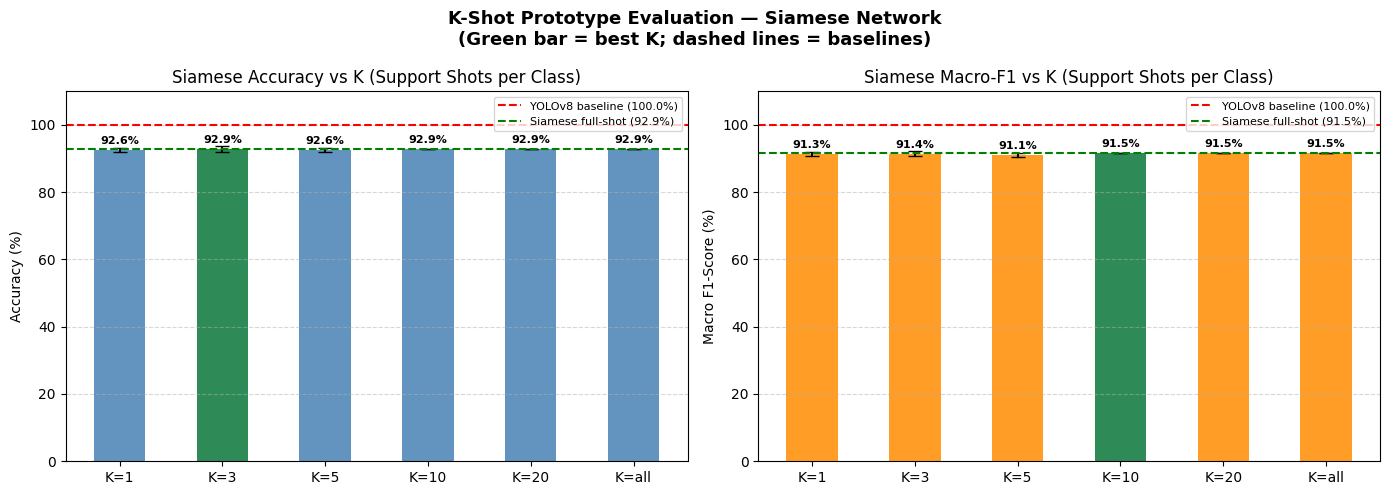

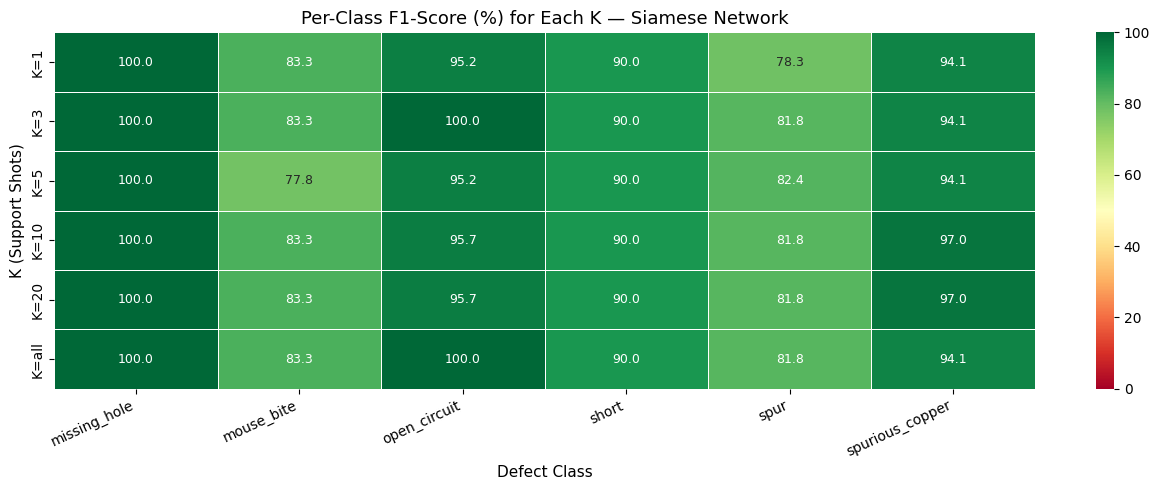


 Best K by accuracy  : K=3  (92.86%)
 Best K by macro-F1  : K=10  (91.54%)


In [27]:
# ── K-Shot results plot ───────────────────────────────────────────────────────
labels   = K_LABELS
accs     = [kshot_results[l]['accuracy'] for l in labels]
f1s      = [kshot_results[l]['macro_f1'] for l in labels]
acc_stds = [kshot_results[l]['acc_std']  for l in labels]
f1_stds  = [kshot_results[l]['f1_std']   for l in labels]

x = np.arange(len(labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Accuracy ─────────────────────────────────────────────────────────
bars = axes[0].bar(x, accs, color='steelblue', alpha=0.85, width=0.5,
                   yerr=acc_stds, capsize=5, error_kw={'linewidth': 1.5})
axes[0].axhline(y=acc_yolo * 100, color='red',   linestyle='--', linewidth=1.5,
                label=f'YOLOv8 baseline ({acc_yolo*100:.1f}%)')
axes[0].axhline(y=acc_siam * 100, color='green', linestyle='--', linewidth=1.5,
                label=f'Siamese full-shot ({acc_siam*100:.1f}%)')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].set_ylim(0, 110)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Siamese Accuracy vs K (Support Shots per Class)')
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.2,
                 f'{acc:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Mark best K
best_idx = accs.index(max(accs))
axes[0].get_children()[best_idx].set_facecolor('seagreen')
axes[0].get_children()[best_idx].set_alpha(1.0)

# ── Right: Macro-F1 ────────────────────────────────────────────────────────
bars2 = axes[1].bar(x, f1s, color='darkorange', alpha=0.85, width=0.5,
                    yerr=f1_stds, capsize=5, error_kw={'linewidth': 1.5})
ma_yolo_f1 = rdict_yolo.get('macro avg', {}).get('f1-score', 0) * 100
ma_siam_f1 = rdict_siam.get('macro avg', {}).get('f1-score', 0) * 100
axes[1].axhline(y=ma_yolo_f1, color='red',   linestyle='--', linewidth=1.5,
                label=f'YOLOv8 baseline ({ma_yolo_f1:.1f}%)')
axes[1].axhline(y=ma_siam_f1, color='green', linestyle='--', linewidth=1.5,
                label=f'Siamese full-shot ({ma_siam_f1:.1f}%)')
axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
axes[1].set_ylim(0, 110)
axes[1].set_ylabel('Macro F1-Score (%)')
axes[1].set_title('Siamese Macro-F1 vs K (Support Shots per Class)')
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
for bar, f1 in zip(bars2, f1s):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.2,
                 f'{f1:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Mark best K
best_f1_idx = f1s.index(max(f1s))
axes[1].get_children()[best_f1_idx].set_facecolor('seagreen')
axes[1].get_children()[best_f1_idx].set_alpha(1.0)

plt.suptitle('K-Shot Prototype Evaluation — Siamese Network\n'
             '(Green bar = best K; dashed lines = baselines)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Per-class F1 heatmap for each K ──────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(13, 5))
heatmap_data = []
for label in labels:
    # Re-run a single pass (deterministic for K=all, one sample for others)
    k_val    = None if label == 'K=all' else int(label.split('=')[1])
    protos_k = build_prototypes(k=k_val, verbose=False)
    row = []
    yt2, yp2 = [], []
    for img_name in test_images:
        gt2 = get_gt_class(img_name, test_label_dir)
        if gt2 is None:
            continue
        img_path = os.path.join(test_img_dir, img_name)
        crop_t   = crop_image(img_path, _crop_detector)
        with torch.no_grad():
            emb2, logits2 = siamese_net.extract_with_logits(crop_t.unsqueeze(0).to(DEVICE))
        probs2           = torch.softmax(logits2, dim=1)
        ce_conf2, ce_cls2 = probs2.max(dim=1)
        pred2 = ce_cls2.item()
        if ce_conf2.item() < 0.4 and protos_k:
            qe = emb2.squeeze(0).cpu()
            bs2, bsim2 = -1, -float('inf')
            for ci2, pt2 in protos_k.items():
                s2 = torch.dot(qe, pt2).item()
                if s2 > bsim2:
                    bsim2, bs2 = s2, ci2
            pred2 = bs2
        yt2.append(gt2); yp2.append(pred2)
    rd2 = classification_report(yt2, yp2, labels=list(range(NUM_CLASSES)),
                                target_names=CLASSES, digits=4,
                                output_dict=True, zero_division=0)
    row = [rd2.get(c, {}).get('f1-score', 0) * 100 for c in CLASSES]
    heatmap_data.append(row)

hm_df = pd.DataFrame(heatmap_data, index=labels, columns=CLASSES)
sns.heatmap(hm_df, annot=True, fmt='.1f', cmap='RdYlGn',
            vmin=0, vmax=100, linewidths=0.5, ax=ax2,
            annot_kws={'size': 9})
ax2.set_xlabel('Defect Class', fontsize=11)
ax2.set_ylabel('K (Support Shots)', fontsize=11)
ax2.set_title('Per-Class F1-Score (%) for Each K — Siamese Network', fontsize=13)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

print(f"\n Best K by accuracy  : {best_label}  ({best_res['accuracy']:.2f}%)")
best_f1_label = labels[best_f1_idx]
print(f" Best K by macro-F1  : {best_f1_label}  ({max(f1s):.2f}%)")


## 18. Adaptive Metric Learning — Attention + Learnable Temperature

This section implements the method actually described in the manuscript (attention-weighted, temperature-scaled cosine similarity — Eqs. 3–6) as a new, separately trained head on top of the **frozen** Siamese backbone from Section 8.


In [28]:
class AttentionReweight(nn.Module):
    """
    Squeeze-and-excitation style attention over embedding dimensions
    (manuscript Eq. 3: a_c = sigma(W2 . ReLU(W1 . p_hat_c))).

    Takes a class prototype embedding and produces a per-dimension
    attention weight vector in (0, 1), used to reweight both the
    prototype and the query embedding before similarity is computed.
    """
    def __init__(self, embed_dim: int, reduction: int = 16):
        super().__init__()
        hidden = max(embed_dim // reduction, 8)
        self.fc1 = nn.Linear(embed_dim, hidden)
        self.fc2 = nn.Linear(hidden, embed_dim)

    def forward(self, proto: torch.Tensor) -> torch.Tensor:
        x = F.relu(self.fc1(proto))
        x = torch.sigmoid(self.fc2(x))
        return x


class AdaptiveMetricHead(nn.Module):
    """
    Adaptive similarity metric: class-specific attention reweighting +
    learnable temperature-scaled cosine similarity (manuscript Eqs. 3-6).

    Operates on already-extracted, L2-normalised embeddings produced by
    the frozen `siamese_net`; it does NOT touch the backbone, embedding
    head, or classification head trained in Section 8.
    """
    def __init__(self, embed_dim: int = EMBED_DIM, init_temperature: float = 10.0):
        super().__init__()
        self.attention = AttentionReweight(embed_dim)
        # log-parameterised temperature keeps tau positive and trains more stably
        self.log_tau = nn.Parameter(torch.log(torch.tensor(float(init_temperature))))

    @property
    def tau(self):
        return self.log_tau.exp()

    def similarity(self, query_emb: torch.Tensor, proto: torch.Tensor,
                    use_attention: bool = True, use_temperature: bool = True) -> torch.Tensor:
        """
        query_emb : (EMBED_DIM,) L2-normalised query embedding
        proto     : (EMBED_DIM,) L2-normalised class prototype
        Returns a scalar similarity score (manuscript Eq. 5: s_c).
        """
        # Prototypes may have been cached on CPU (e.g. from build_prototypes);
        # align both tensors to this module's device before any op touches them.
        device = self.log_tau.device
        query_emb = query_emb.to(device)
        proto = proto.to(device)

        if use_attention:
            a     = self.attention(proto)
            q_rew = F.normalize(query_emb * a, p=2, dim=-1)
            p_rew = F.normalize(proto * a,     p=2, dim=-1)
        else:
            q_rew, p_rew = query_emb, proto

        cos_sim = torch.dot(q_rew, p_rew)
        return self.tau * cos_sim if use_temperature else cos_sim

    def classify(self, query_emb: torch.Tensor, prototypes: dict,
                 use_attention: bool = True, use_temperature: bool = True):
        """Return (pred_class, probs_dict) via SoftMax over all class scores (Eq. 6)."""
        classes = sorted(prototypes.keys())
        scores  = torch.stack([
            self.similarity(query_emb, prototypes[c], use_attention, use_temperature)
            for c in classes
        ])
        probs = torch.softmax(scores, dim=0)
        pred  = classes[torch.argmax(probs).item()]
        return pred, {c: probs[i].item() for i, c in enumerate(classes)}


adaptive_head = AdaptiveMetricHead(embed_dim=EMBED_DIM, init_temperature=10.0).to(DEVICE)
print(f"AdaptiveMetricHead defined — "
      f"{sum(p.numel() for p in adaptive_head.parameters()):,} trainable parameters "
      f"(attention module + 1 temperature scalar).")

AdaptiveMetricHead defined — 8,465 trainable parameters (attention module + 1 temperature scalar).


## 19. Train the Adaptive Metric Head

The Siamese backbone, embedding head, and classification head from Section 8 are **frozen** here — only `adaptive_head` (attention module + temperature) is trained, via episodic K-shot classification on the training split, matching the "lightweight, adds only minimal parameters" claim in the manuscript's Conclusion.


Training adaptive metric head (attention + learnable temperature, margin=0.15)
  epochs=40  episodes/epoch=30  K=5  query/class=3
  epoch  1/40  loss=0.2144  tau=9.839  val_acc=95.65%
  epoch  5/40  loss=0.1389  tau=9.282  val_acc=95.65%
  epoch 10/40  loss=0.1238  tau=8.797  val_acc=95.65%
  epoch 15/40  loss=0.1195  tau=8.476  val_acc=95.65%
  epoch 20/40  loss=0.1469  tau=8.224  val_acc=95.65%
  epoch 25/40  loss=0.0902  tau=8.015  val_acc=95.65%
  epoch 30/40  loss=0.1643  tau=7.929  val_acc=95.65%
  epoch 35/40  loss=0.1511  tau=7.885  val_acc=95.65%
  epoch 40/40  loss=0.1165  tau=7.880  val_acc=95.65%

Adaptive metric head training complete.


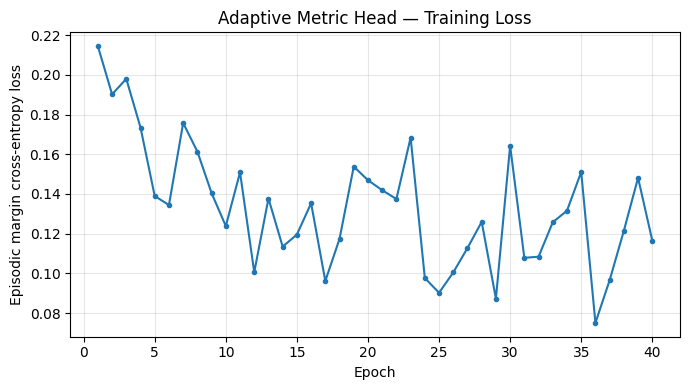

In [29]:
# ── Freeze the trained Siamese network entirely ─────────────────────────────────
siamese_net.eval()
for p in siamese_net.parameters():
    p.requires_grad_(False)

ADAPTIVE_EPOCHS     = 40
ADAPTIVE_K          = 5
ADAPTIVE_N_QUERY    = 3
ADAPTIVE_LR         = 1e-3
EPISODES_PER_EPOCH  = 30
MARGIN              = 0.15   # additive margin on the target class's raw cosine score —
                              # forces the model to win by a margin, not just barely,
                              # so the loss keeps giving gradient after it's "good enough"
ATTN_DIVERSITY_W    = 0.05   # penalises attention vectors collapsing to the same
                              # value across classes (i.e. becoming a no-op global transform)

opt       = torch.optim.Adam(adaptive_head.parameters(), lr=ADAPTIVE_LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=ADAPTIVE_EPOCHS)

# ── Group training crops by class ──────────────────────────────────────────────
train_img_dir_a   = os.path.join(output_dir, 'images', 'train')
train_label_dir_a = os.path.join(output_dir, 'labels', 'train')
class_files_a = {c: [] for c in range(NUM_CLASSES)}
for fname in os.listdir(train_img_dir_a):
    if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
        continue
    gt = get_gt_class(fname, train_label_dir_a)
    if gt is not None:
        class_files_a[gt].append(fname)

# ── Held-out validation split, used ONLY to monitor training — never for loss ───
val_img_dir_a   = os.path.join(output_dir, 'images', 'val')
val_label_dir_a = os.path.join(output_dir, 'labels', 'val')
val_images_a    = sorted(
    f for f in os.listdir(val_img_dir_a)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
)

rng_a = np.random.default_rng(seed=42)


@torch.no_grad()
def _embed_a(fname, img_dir):
    """Embed one crop through the FROZEN backbone (no grad)."""
    crop_t = crop_image(os.path.join(img_dir, fname), _crop_detector)
    return siamese_net.extract(crop_t.unsqueeze(0).to(DEVICE)).squeeze(0)


def _sample_episode(k=ADAPTIVE_K, n_query=ADAPTIVE_N_QUERY):
    """Sample k support + n_query query crops per class; build prototypes."""
    protos, queries, query_labels = {}, [], []
    for c in range(NUM_CLASSES):
        files = class_files_a[c]
        if len(files) < k + 1:
            continue
        n_take    = min(k + n_query, len(files))
        chosen    = rng_a.choice(files, size=n_take, replace=False)
        support_f = chosen[:k]
        query_f   = chosen[k:] if n_take > k else chosen[:1]

        embs = torch.stack([_embed_a(f, train_img_dir_a) for f in support_f])
        protos[c] = F.normalize(embs.mean(dim=0), p=2, dim=0)

        for f in query_f:
            queries.append(_embed_a(f, train_img_dir_a))
            query_labels.append(c)

    return protos, queries, query_labels


@torch.no_grad()
def _val_accuracy():
    """Quick full-shot val accuracy check — never used for training, monitoring only."""
    protos = build_prototypes(k=None, verbose=False)
    protos = {c: p.to(DEVICE) for c, p in protos.items()}
    adaptive_head.eval()
    correct = 0
    n = 0
    for img_name in val_images_a:
        gt = get_gt_class(img_name, val_label_dir_a)
        if gt is None:
            continue
        q_emb = _embed_a(img_name, val_img_dir_a)
        pred, _ = adaptive_head.classify(q_emb, protos, use_attention=True, use_temperature=True)
        correct += int(pred == gt)
        n += 1
    adaptive_head.train()
    return 100.0 * correct / max(n, 1)


print(f"Training adaptive metric head (attention + learnable temperature, margin={MARGIN})")
print(f"  epochs={ADAPTIVE_EPOCHS}  episodes/epoch={EPISODES_PER_EPOCH}  "
      f"K={ADAPTIVE_K}  query/class={ADAPTIVE_N_QUERY}")

adaptive_head.train()
loss_history, val_acc_history = [], []

for epoch in range(1, ADAPTIVE_EPOCHS + 1):
    ep_loss, n_steps = 0.0, 0

    for _ in range(EPISODES_PER_EPOCH):
        protos, queries, qlabels = _sample_episode()
        if len(queries) == 0 or len(protos) < 2:
            continue
        classes = sorted(protos.keys())

        # Compute each class's attention vector once per episode (not per query).
        attn_vecs = {c: adaptive_head.attention(protos[c]) for c in classes}
        stacked_a = torch.stack([attn_vecs[c] for c in classes])
        mean_a    = stacked_a.mean(dim=0, keepdim=True)
        # Negative variance: minimising this term REWARDS attention vectors that
        # differ across classes, discouraging collapse to one global transform.
        diversity_loss = -((stacked_a - mean_a) ** 2).mean()

        batch_loss = 0.0
        for q_emb, y in zip(queries, qlabels):
            scores = []
            for c in classes:
                q_rew   = F.normalize(q_emb * attn_vecs[c], p=2, dim=-1)
                p_rew   = F.normalize(protos[c] * attn_vecs[c], p=2, dim=-1)
                cos_sim = torch.dot(q_rew, p_rew)
                if c == y:
                    cos_sim = cos_sim - MARGIN
                scores.append(adaptive_head.tau * cos_sim)
            scores = torch.stack(scores)
            target = torch.tensor([classes.index(y)], device=DEVICE)
            batch_loss = batch_loss + F.cross_entropy(scores.unsqueeze(0), target)
        batch_loss = batch_loss / max(len(queries), 1) + ATTN_DIVERSITY_W * diversity_loss

        opt.zero_grad()
        batch_loss.backward()
        opt.step()

        ep_loss += batch_loss.item()
        n_steps += 1

    scheduler.step()
    avg_loss = ep_loss / max(n_steps, 1)
    loss_history.append(avg_loss)

    if epoch == 1 or epoch % 5 == 0 or epoch == ADAPTIVE_EPOCHS:
        val_acc = _val_accuracy()
        val_acc_history.append((epoch, val_acc))
        print(f"  epoch {epoch:2d}/{ADAPTIVE_EPOCHS}  loss={avg_loss:.4f}  "
              f"tau={adaptive_head.tau.item():.3f}  val_acc={val_acc:.2f}%")

print("\nAdaptive metric head training complete.")

plt.figure(figsize=(7, 4))
plt.plot(range(1, ADAPTIVE_EPOCHS + 1), loss_history, marker='.')
plt.xlabel('Epoch'); plt.ylabel('Episodic margin cross-entropy loss')
plt.title('Adaptive Metric Head — Training Loss')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 20. Ablation Study — Baseline Cosine vs. Attention vs. Attention + Temperature

Three configurations, evaluated with the same frozen backbone and the same `adaptive_head` (trained once, in Section 19, with both attention and temperature enabled) — attention and temperature are switched on/off only at **evaluation** time, which isolates each component's contribution without needing to retrain from scratch for each configuration:

1. **Baseline cosine similarity** — no attention, no temperature (`tau=1`).
2. **Attention only** — attention-reweighted embeddings, `tau=1`.
3. **Attention + Temperature (full method)** — both enabled.

**Note on interpreting this ablation:** multiplying every class's similarity score by the same positive temperature scalar can never change which class wins, so Accuracy/Macro-F1 for configs 2→3 will always tie by construction — the actual effect of temperature shows up in the *confidence/entropy* columns and confusion matrices below, not in accuracy. If configs 1→2 also tie exactly, check the per-example agreement counts (Section 20.1) before assuming the ablation is broken — on a small, cleanly-separated test set it's possible for attention to leave every prediction unchanged even though the embedding geometry shifted.


In [30]:
import math

def evaluate_config(k, use_attention, use_temperature, config_name, n_repeats=5):
    """
    Evaluate the adaptive metric head on the FIXED test set, repeated over
    n_repeats random draws of the K support images per class (test images
    never change — only which training images become the prototypes).
    Reports mean ± std so a tie/difference is statistically meaningful
    rather than a single noisy point estimate.
    """
    accs, f1s, ps, rs, confs, ents = [], [], [], [], [], []
    last_yt, last_yp, last_rdict = None, None, None

    for _ in range(n_repeats):
        protos = build_prototypes(k=k, verbose=False)
        protos = {c: p.to(DEVICE) for c, p in protos.items()}
        adaptive_head.eval()

        yt, yp, rep_confs, rep_ents = [], [], [], []
        for img_name in test_images:
            gt = get_gt_class(img_name, test_label_dir)
            if gt is None:
                continue
            crop_t = crop_image(os.path.join(test_img_dir, img_name), _crop_detector)
            with torch.no_grad():
                q_emb = siamese_net.extract(crop_t.unsqueeze(0).to(DEVICE)).squeeze(0)
                pred, probs = adaptive_head.classify(q_emb, protos, use_attention, use_temperature)
            yt.append(gt); yp.append(pred)
            rep_confs.append(probs[pred])
            rep_ents.append(-sum(p * math.log(p + 1e-12) for p in probs.values()))

        rdict = classification_report(yt, yp, labels=list(range(NUM_CLASSES)),
                                       target_names=CLASSES, digits=4,
                                       output_dict=True, zero_division=0)
        accs.append(accuracy_score(yt, yp) * 100)
        f1s.append(rdict['macro avg']['f1-score'] * 100)
        ps.append(rdict['macro avg']['precision'] * 100)
        rs.append(rdict['macro avg']['recall'] * 100)
        confs.append(sum(rep_confs) / len(rep_confs) * 100)
        ents.append(sum(rep_ents) / len(rep_ents))
        last_yt, last_yp, last_rdict = yt, yp, rdict

    print(f"\n{'='*70}")
    print(f"  {config_name}  (K={k}, {n_repeats} repeats)")
    print(f"{'='*70}")
    print(f"  Accuracy : {np.mean(accs):.2f}% ± {np.std(accs):.2f}   "
          f"Macro-F1 : {np.mean(f1s):.2f}% ± {np.std(f1s):.2f}")
    print(f"  Macro-P  : {np.mean(ps):.2f}%   Macro-R : {np.mean(rs):.2f}%")
    print(f"  Avg confidence : {np.mean(confs):.2f}%   Avg entropy : {np.mean(ents):.3f} nats")

    return {'name': config_name, 'k': k,
            'accuracy': np.mean(accs), 'accuracy_std': np.std(accs),
            'macro_f1': np.mean(f1s), 'macro_f1_std': np.std(f1s),
            'macro_p': np.mean(ps), 'macro_r': np.mean(rs),
            'avg_conf': np.mean(confs), 'avg_entropy': np.mean(ents),
            'y_true': last_yt, 'y_pred': last_yp, 'report': last_rdict}


ABLATION_K = 5

results_baseline    = evaluate_config(ABLATION_K, use_attention=False, use_temperature=False,
                                       config_name="1. Baseline cosine similarity")
results_attn_only   = evaluate_config(ABLATION_K, use_attention=True,  use_temperature=False,
                                       config_name="2. Attention only")
results_full_method = evaluate_config(ABLATION_K, use_attention=True,  use_temperature=True,
                                       config_name="3. Attention + Temperature (full method)")

print(f"\n{'Configuration':<45} {'Accuracy':>14} {'Macro-F1':>14} {'Macro-P':>10} {'Macro-R':>10}")
print("-" * 100)
for r in [results_baseline, results_attn_only, results_full_method]:
    print(f"{r['name']:<45} {r['accuracy']:>7.2f}%±{r['accuracy_std']:<4.2f} "
          f"{r['macro_f1']:>7.2f}%±{r['macro_f1_std']:<4.2f} "
          f"{r['macro_p']:>9.2f}% {r['macro_r']:>9.2f}%")


  1. Baseline cosine similarity  (K=5, 5 repeats)
  Accuracy : 92.29% ± 0.70   Macro-F1 : 90.85% ± 0.86
  Macro-P  : 92.73%   Macro-R : 90.83%
  Avg confidence : 37.98%   Avg entropy : 1.642 nats

  2. Attention only  (K=5, 5 repeats)
  Accuracy : 92.86% ± 0.00   Macro-F1 : 91.30% ± 0.00
  Macro-P  : 93.48%   Macro-R : 91.23%
  Avg confidence : 38.44%   Avg entropy : 1.643 nats

  3. Attention + Temperature (full method)  (K=5, 5 repeats)
  Accuracy : 92.86% ± 0.00   Macro-F1 : 91.30% ± 0.00
  Macro-P  : 93.48%   Macro-R : 91.23%
  Avg confidence : 96.81%   Avg entropy : 0.079 nats

Configuration                                       Accuracy       Macro-F1    Macro-P    Macro-R
----------------------------------------------------------------------------------------------------
1. Baseline cosine similarity                   92.29%±0.70   90.85%±0.86     92.73%     90.83%
2. Attention only                               92.86%±0.00   91.30%±0.00     93.48%     91.23%
3. Attention + Tem

### 20.1 Per-Example Prediction Agreement

Accuracy and Macro-F1 can tie across configurations even when the underlying
per-image predictions differ (e.g. one wrong prediction swapped for a different
wrong prediction). This cell checks directly how many individual test images
actually changed prediction when attention and/or temperature are switched on,
so a tie in the summary table above can be read correctly as "no images changed"
rather than assumed.

In [31]:
def compare_predictions(res_a, res_b, label_a, label_b):
    yp_a, yp_b = res_a['y_pred'], res_b['y_pred']
    assert len(yp_a) == len(yp_b), "Result sets must cover the same test images in the same order"
    n_diff = sum(a != b for a, b in zip(yp_a, yp_b))
    print(f"  {label_a:<32} vs {label_b:<32} : "
          f"{n_diff}/{len(yp_a)} predictions differ")
    return n_diff


print(f"K = {ABLATION_K}")
compare_predictions(results_baseline, results_attn_only,   'Baseline',           'Attention only')
compare_predictions(results_baseline, results_full_method,  'Baseline',           'Attention + Temp')
compare_predictions(results_attn_only, results_full_method, 'Attention only',     'Attention + Temp')


K = 5
  Baseline                         vs Attention only                   : 7/70 predictions differ
  Baseline                         vs Attention + Temp                 : 7/70 predictions differ
  Attention only                   vs Attention + Temp                 : 0/70 predictions differ


0

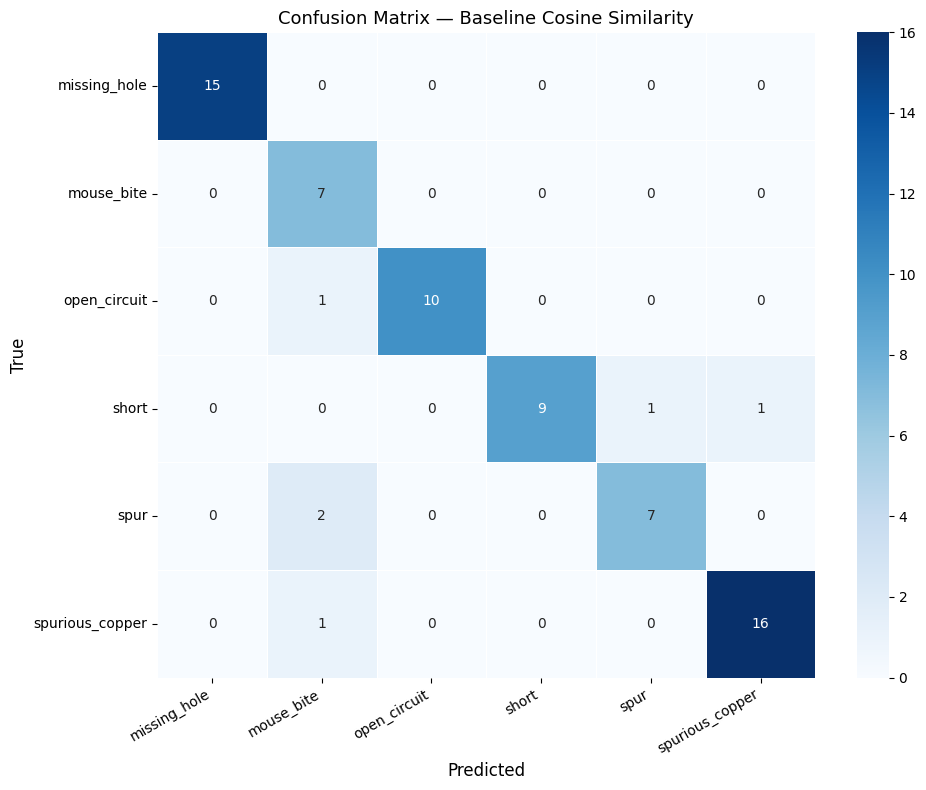

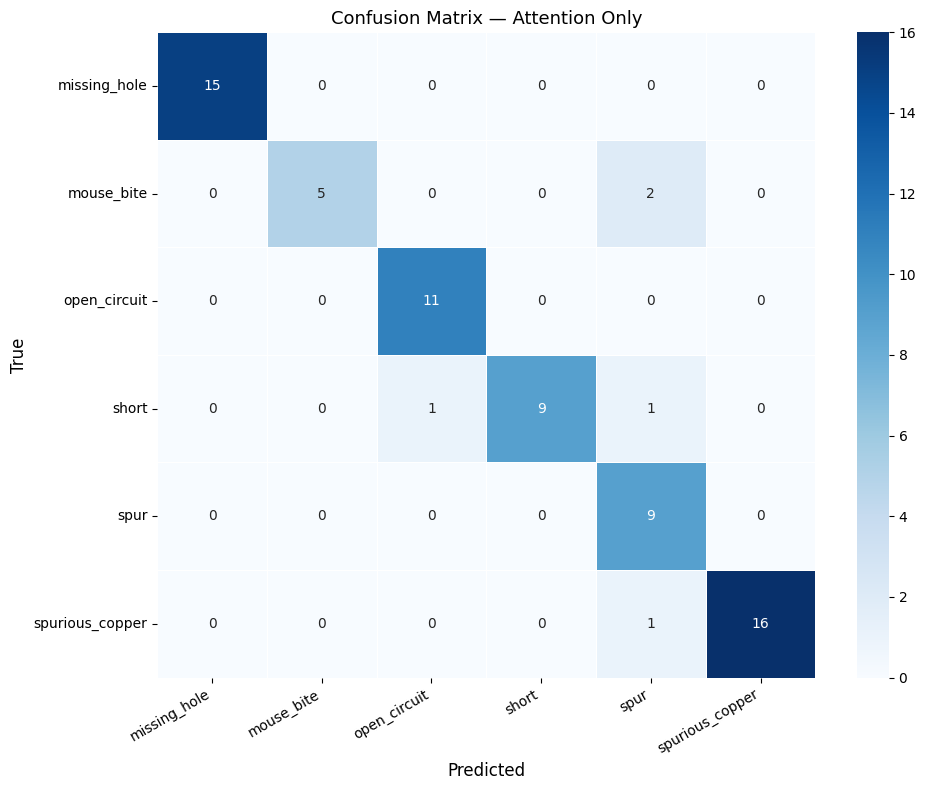

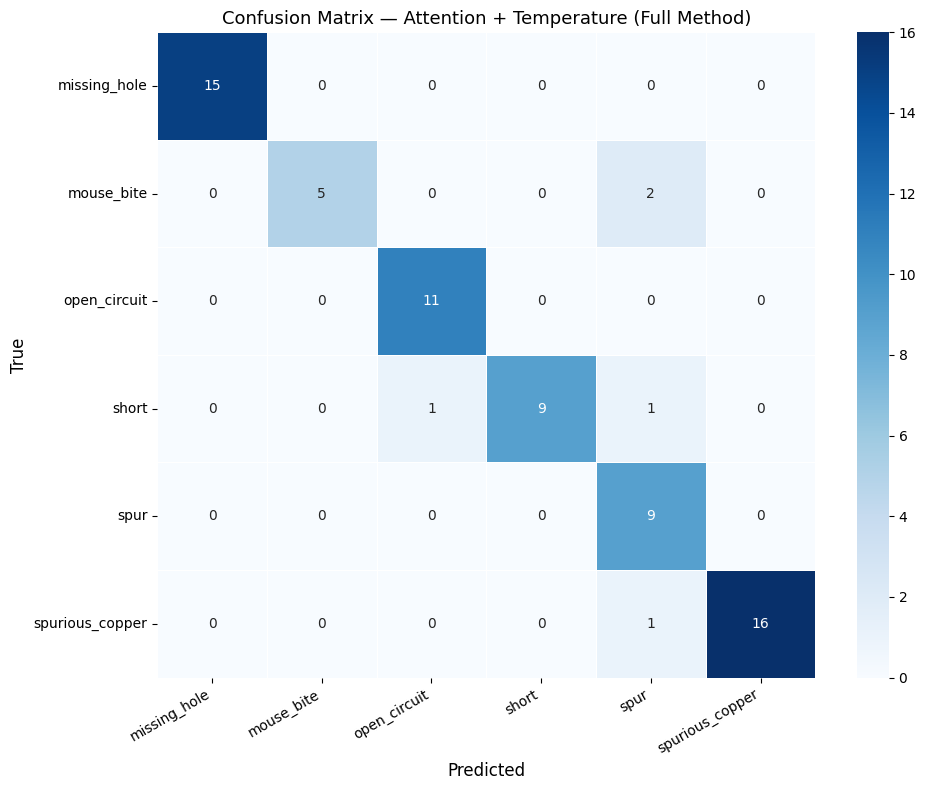

In [32]:
# ── Confusion matrices for each ablation configuration ───────────────────────────
plot_cm(results_baseline['y_true'],    results_baseline['y_pred'],
        'Confusion Matrix — Baseline Cosine Similarity',            cmap='Blues')
plot_cm(results_attn_only['y_true'],   results_attn_only['y_pred'],
        'Confusion Matrix — Attention Only',                        cmap='Blues')
plot_cm(results_full_method['y_true'], results_full_method['y_pred'],
        'Confusion Matrix — Attention + Temperature (Full Method)', cmap='Blues')


In [33]:
# ── Optional: repeat the ablation at K=1, to match the manuscript's reported
#    K=1 and K=5 evaluation points (Table 1) ─────────────────────────────────────
ABLATION_K_ONE = 1

results_baseline_k1    = evaluate_config(ABLATION_K_ONE, use_attention=False, use_temperature=False,
                                          config_name="1. Baseline cosine similarity")
results_attn_only_k1   = evaluate_config(ABLATION_K_ONE, use_attention=True,  use_temperature=False,
                                          config_name="2. Attention only")
results_full_method_k1 = evaluate_config(ABLATION_K_ONE, use_attention=True,  use_temperature=True,
                                          config_name="3. Attention + Temperature (full method)")

print(f"\n{'Configuration':<45} {'Accuracy':>10} {'Macro-F1':>10} {'Macro-P':>10} "
      f"{'Macro-R':>10} {'Avg Conf':>10} {'Avg Entropy':>12}")
print("-" * 112)
for r in [results_baseline_k1, results_attn_only_k1, results_full_method_k1]:
    print(f"{r['name']:<45} {r['accuracy']:>9.2f}% {r['macro_f1']:>9.2f}% "
          f"{r['macro_p']:>9.2f}% {r['macro_r']:>9.2f}% {r['avg_conf']:>9.2f}% "
          f"{r['avg_entropy']:>11.3f}n")

print(f"\nK = {ABLATION_K_ONE}")
compare_predictions(results_baseline_k1, results_attn_only_k1,   'Baseline',       'Attention only')
compare_predictions(results_baseline_k1, results_full_method_k1, 'Baseline',       'Attention + Temp')
compare_predictions(results_attn_only_k1, results_full_method_k1,'Attention only', 'Attention + Temp')



  1. Baseline cosine similarity  (K=1, 5 repeats)
  Accuracy : 91.43% ± 0.90   Macro-F1 : 89.92% ± 0.97
  Macro-P  : 92.24%   Macro-R : 90.00%
  Avg confidence : 37.16%   Avg entropy : 1.646 nats

  2. Attention only  (K=1, 5 repeats)
  Accuracy : 92.57% ± 0.57   Macro-F1 : 90.90% ± 0.79
  Macro-P  : 92.75%   Macro-R : 90.96%
  Avg confidence : 37.70%   Avg entropy : 1.649 nats

  3. Attention + Temperature (full method)  (K=1, 5 repeats)
  Accuracy : 92.86% ± 0.00   Macro-F1 : 91.30% ± 0.00
  Macro-P  : 93.48%   Macro-R : 91.23%
  Avg confidence : 96.81%   Avg entropy : 0.087 nats

Configuration                                   Accuracy   Macro-F1    Macro-P    Macro-R   Avg Conf  Avg Entropy
----------------------------------------------------------------------------------------------------------------
1. Baseline cosine similarity                     91.43%     89.92%     92.24%     90.00%     37.16%       1.646n
2. Attention only                                 92.57%     90.90% 

0

## 21. Embedding Space Visualisation (t-SNE / UMAP) — Before vs. After Attention

For each test image, its embedding is projected to 2D both **before** attention (the raw L2-normalised embedding, Eq. 2) and **after** attention (reweighted using the attention vector derived from that image's own *ground-truth* class prototype, Eq. 4 — i.e. "if this query were being compared against its correct class"). This isolates the effect of attention-based reweighting on class separability, independent of classification correctness.


In [34]:
from sklearn.manifold import TSNE

def collect_test_embeddings(use_attention: bool):
    """
    Collect (embedding, label) pairs for the test set.
      use_attention=False -> raw L2-normalised embeddings (Eq. 2)
      use_attention=True  -> attention-reweighted embeddings (Eq. 4), each
                              reweighted using its OWN ground-truth class's
                              attention vector.
    """
    protos = build_prototypes(k=None, verbose=False)  # full-shot prototypes -> stable attention vectors
    protos = {c: p.to(DEVICE) for c, p in protos.items()}
    adaptive_head.eval()

    embs, labels = [], []
    for img_name in test_images:
        gt = get_gt_class(img_name, test_label_dir)
        if gt is None or gt not in protos:
            continue
        crop_t = crop_image(os.path.join(test_img_dir, img_name), _crop_detector)
        with torch.no_grad():
            q_emb = siamese_net.extract(crop_t.unsqueeze(0).to(DEVICE)).squeeze(0)
            if use_attention:
                a     = adaptive_head.attention(protos[gt])
                q_emb = F.normalize(q_emb * a, p=2, dim=-1)
        embs.append(q_emb.cpu().numpy())
        labels.append(gt)

    return np.stack(embs), np.array(labels)


emb_before, labels_before = collect_test_embeddings(use_attention=False)
emb_after,  labels_after  = collect_test_embeddings(use_attention=True)

print(f"Collected {len(labels_before)} test embeddings "
      f"(before and after attention-based reweighting).")

perplexity = max(5, min(30, len(labels_before) // 4))
tsne_before = TSNE(n_components=2, perplexity=perplexity, random_state=42,
                    init='pca').fit_transform(emb_before)
tsne_after  = TSNE(n_components=2, perplexity=perplexity, random_state=42,
                    init='pca').fit_transform(emb_after)

Collected 70 test embeddings (before and after attention-based reweighting).


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


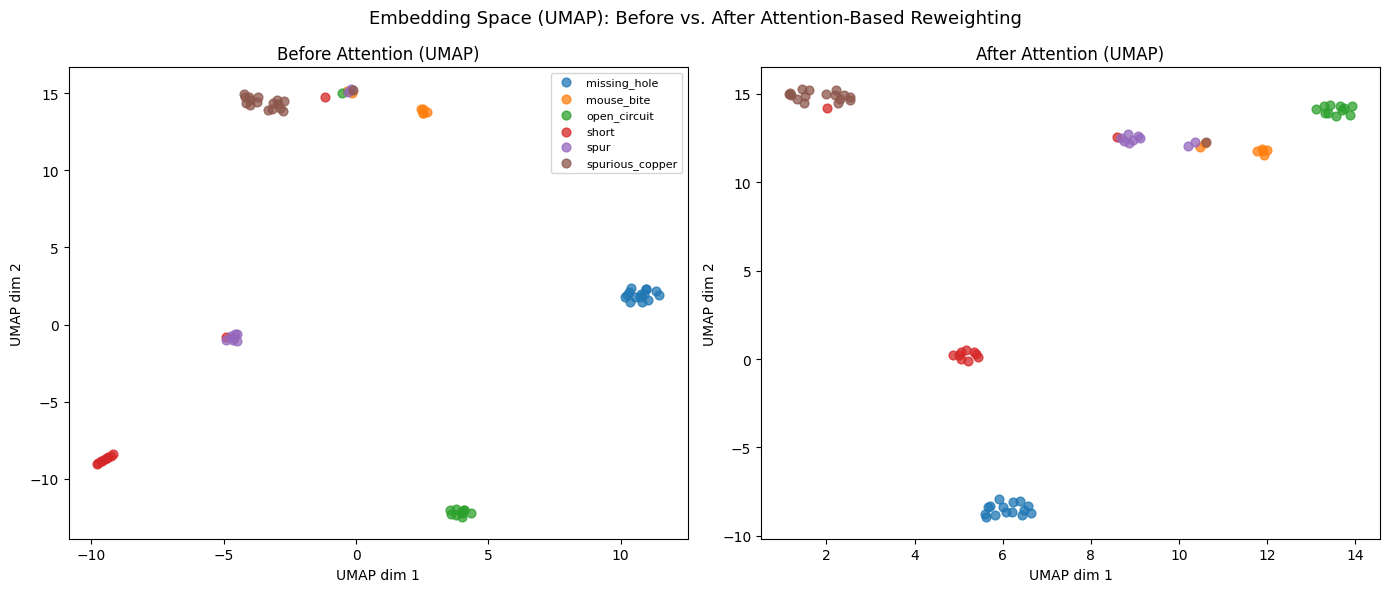

In [35]:
# ── Optional: UMAP version of the same comparison, if umap-learn is available ────
try:
    import umap
    umap_before = umap.UMAP(n_components=2, random_state=42).fit_transform(emb_before)
    umap_after  = umap.UMAP(n_components=2, random_state=42).fit_transform(emb_after)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, xy, labels, title in [
        (axes[0], umap_before, labels_before, 'Before Attention (UMAP)'),
        (axes[1], umap_after,  labels_after,  'After Attention (UMAP)'),
    ]:
        for c in range(NUM_CLASSES):
            mask = labels == c
            ax.scatter(xy[mask, 0], xy[mask, 1], label=CLASSES[c], s=40, alpha=0.75)
        ax.set_title(title)
        ax.set_xlabel('UMAP dim 1'); ax.set_ylabel('UMAP dim 2')
    axes[0].legend(loc='best', fontsize=8)
    plt.suptitle('Embedding Space (UMAP): Before vs. After Attention-Based Reweighting', fontsize=13)
    plt.tight_layout(); plt.show()
except ImportError:
    print("umap-learn is not installed — skipping the UMAP plot (the t-SNE plot "
          "above already satisfies the manuscript's visualisation requirement). "
          "Run `!pip install umap-learn` first if you want the UMAP version too.")
